# 🩺 Breast Cancer Ultrasound — Pipeline IA Professionnel
### Segmentation · Classification · Grad-CAM · Rapport Médical

---

**Datasets :**
- **BUSI** — Breast Ultrasound Images Dataset (Al-Dhabyani et al., 2020) — 780 images
- **BUS-BRA** *(nouveau)* — Gómez-Flores et al., Medical Physics, 2024 — 1875 images
- **Total fusionné : ~2655 images**

**Classes :** Normal · Bénin · Malin  
**Architecture :**
- **Segmentation** : ResNet34-UNet (SMP) — Transfer Learning + Loss BCE+Dice
- **Classification** : EfficientNetB0 fine-tuné (Transfer Learning)
- **Explainabilité** : Grad-CAM sur couche finale
- **Post-processing** : Morphologie mathématique
- **Rapport** : Dashboard IA médical complet

---
> ⚠️ **Note scientifique** : Ce pipeline est un outil d'aide au diagnostic à but académique.  
> Les résultats ne remplacent pas l'avis d'un médecin radiologue.
>
> 📚 **Référence BUS-BRA** : Gómez-Flores W. et al., *"BUS-BRA: A Breast Ultrasound Dataset for Assessing Computer-aided Diagnosis Systems"*, Medical Physics, vol. 51, pp. 3110–3123, 2024. DOI: 10.1002/mp.16812

## 📦 0. Installation des dépendances

In [2]:
import subprocess, sys

def pip(*a):  subprocess.run([sys.executable,'-m','pip','install','-q','--no-deps',*a],check=False)
def pip_n(*a): subprocess.run([sys.executable,'-m','pip','install','-q',*a],check=False)

pip_n('albumentations','torchmetrics','segmentation-models-pytorch==0.3.3',
      'huggingface-hub','safetensors')
pip('einops','timm','pretrainedmodels','efficientnet-pytorch==0.7.1')

import importlib
for pkg in ['segmentation_models_pytorch','albumentations','timm','torchmetrics']:
    print(f'  {"✅" if importlib.util.find_spec(pkg) else "❌"} {pkg}')
print('\n✅ Installation terminée')

  ✅ segmentation_models_pytorch
  ✅ albumentations
  ✅ timm
  ✅ torchmetrics

✅ Installation terminée


## 🔗 1. Google Drive & Configuration

In [3]:
from google.colab import drive
drive.mount('/content/drive')
import os, zipfile

# ─── Chemins ──────────────────────────────────────────────────────────────────
PROJECT_DIR      = '/content/drive/MyDrive/MonProjetcancer'
SEGMENTATION_ZIP = os.path.join(PROJECT_DIR, 'archive_segmentation.zip')
BUSBRA_ZIP       = os.path.join(PROJECT_DIR, 'BUSBRA.zip')   # ← ton fichier zip

OUTPUT_DIR  = '/content/outputs'
DATASET_DIR = '/content/dataset'
BUSBRA_EXTRACT = '/content/busbra'   # dossier de décompression local
os.makedirs(OUTPUT_DIR,     exist_ok=True)
os.makedirs(DATASET_DIR,    exist_ok=True)
os.makedirs(BUSBRA_EXTRACT, exist_ok=True)

# ─── Décompression BUSBRA.zip (NOUVEAU) ───────────────────────────────────────
if os.path.exists(BUSBRA_ZIP):
    # Vérifier si déjà dézippé (évite de refaire à chaque run)
    already_done = any(
        f.endswith('.png')
        for root,_,files in os.walk(BUSBRA_EXTRACT)
        for f in files
    )
    if not already_done:
        print('📂 Décompression BUSBRA.zip ...')
        with zipfile.ZipFile(BUSBRA_ZIP, 'r') as z:
            z.extractall(BUSBRA_EXTRACT)
        print('✅ BUS-BRA dézippé.')
    else:
        print('✅ BUS-BRA déjà dézippé — skip.')

    # Détecter automatiquement le dossier et le CSV à l'intérieur du zip
    BUSBRA_DIR = BUSBRA_EXTRACT
    for root, dirs, files in os.walk(BUSBRA_EXTRACT):
        if any(f.endswith('.csv') for f in files):
            BUSBRA_DIR = root
            break

    # Trouver le CSV principal
    BUSBRA_CSV = None
    for root, dirs, files in os.walk(BUSBRA_EXTRACT):
        for f in files:
            if f.endswith('.csv'):
                BUSBRA_CSV = os.path.join(root, f)
                break
        if BUSBRA_CSV: break
else:
    BUSBRA_DIR = None
    BUSBRA_CSV = None

print('\n✅ Drive monté')
print(f'  {"✅" if os.path.exists(SEGMENTATION_ZIP) else "❌ MANQUANT"} archive_segmentation.zip (BUSI)')
print(f'  {"✅" if os.path.exists(BUSBRA_ZIP)        else "❌ MANQUANT"} BUSBRA.zip (BUS-BRA)')
print(f'  {"✅" if BUSBRA_CSV                         else "⚠️  CSV non trouvé"} CSV BUS-BRA : {BUSBRA_CSV}')


Mounted at /content/drive
📂 Décompression BUSBRA.zip ...
✅ BUS-BRA dézippé.

✅ Drive monté
  ✅ archive_segmentation.zip (BUSI)
  ✅ BUSBRA.zip (BUS-BRA)
  ✅ CSV BUS-BRA : /content/busbra/BUSBRA/bus_data.csv


## 📚 2. Imports & Configuration globale

In [4]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tv_models
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ─── Config ───────────────────────────────────────────────────────────────────
class CFG:
    IMG_SIZE   = 256
    BATCH_SIZE = 16
    EPOCHS_SEG = 30        # segmentation
    EPOCHS_CLF = 30        # classification fine-tuning
    LR_SEG     = 1e-4
    LR_CLF     = 3e-4
    SEED       = 42
    VAL_SPLIT  = 0.15
    TEST_SPLIT = 0.10
    DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]
    LABEL2IDX = {'normal':0, 'benign':1, 'malignant':2}
    IDX2LABEL = {0:'Normal', 1:'Bénin', 2:'Malin'}
    # ── Pondération loss BCE+Dice (nouveau) ───────────────────────────────────
    BCE_WEIGHT  = 0.5
    DICE_WEIGHT = 0.5

torch.manual_seed(CFG.SEED)
np.random.seed(CFG.SEED)
plt.style.use('seaborn-v0_8-whitegrid')
print(f'✅ PyTorch {torch.__version__} | Device : {CFG.DEVICE}')

✅ PyTorch 2.10.0+cu128 | Device : cuda


## 🗂️ 3. Chargement & Fusion BUSI + BUS-BRA

> **Nouveau** : on fusionne les deux datasets dans un seul DataFrame avant le split.  
> BUS-BRA apporte 1875 images supplémentaires avec annotations BI-RADS et 4 scanners différents.

In [5]:
# ─── 3a. Chargement BUSI (identique à avant) ──────────────────────────────────
import zipfile
BUSI_PATH = os.path.join(DATASET_DIR, 'Dataset_BUSI_with_GT')

if not os.path.exists(BUSI_PATH):
    if os.path.exists(SEGMENTATION_ZIP):
        print('📂 Décompression BUSI...')
        with zipfile.ZipFile(SEGMENTATION_ZIP,'r') as z:
            z.extractall(DATASET_DIR)
        print('✅ BUSI dézippé.')

CATEGORIES = ['normal','benign','malignant']
for root, dirs, _ in os.walk(DATASET_DIR):
    if all(c in dirs for c in CATEGORIES):
        BUSI_PATH = root; break

records_busi = []
for cat in CATEGORIES:
    cat_dir = Path(BUSI_PATH) / cat
    if not cat_dir.exists(): continue
    for img_path in sorted(cat_dir.glob('*.png')):
        if '_mask' in img_path.name: continue
        mask_path = cat_dir / img_path.name.replace('.png','_mask.png')
        records_busi.append({
            'image'    : str(img_path),
            'mask'     : str(mask_path) if mask_path.exists() else None,
            'label'    : cat,
            'label_idx': CFG.LABEL2IDX[cat],
            'source'   : 'BUSI'
        })

df_busi = pd.DataFrame(records_busi)
print(f'📊 BUSI chargé : {len(df_busi)} images')
print(df_busi['label'].value_counts().to_string())

📂 Décompression BUSI...
✅ BUSI dézippé.
📊 BUSI chargé : 780 images
label
benign       437
malignant    210
normal       133


In [6]:
records_busbra = []

if BUSBRA_DIR and os.path.exists(BUSBRA_DIR):
    if BUSBRA_CSV and os.path.exists(BUSBRA_CSV):
        df_csv = pd.read_csv(BUSBRA_CSV)
        print(f'📄 CSV BUS-BRA : {len(df_csv)} lignes')
        print(df_csv.head(2).to_string())

        # ── Colonnes réelles du CSV BUS-BRA ───────────────────────────────
        # ID         → ex: 'bus_0001-l'  (nom de base de l'image)
        # Pathology  → 'benign' ou 'malignant'
        # BIRADS     → catégorie BI-RADS (2 à 5)
        # Device     → scanner utilisé
        IMG_COL  = 'ID'          # ← vrai nom de colonne
        LABE_COL = 'Pathology'   # ← vrai nom de colonne

        # Détecter automatiquement le dossier images et masks
        BUSBRA_IMGS, BUSBRA_MASKS = None, None
        for root, dirs, files in os.walk(BUSBRA_EXTRACT):
            pngs = [f for f in files if f.endswith('.png') and 'mask' not in f]
            if len(pngs) > 10:
                BUSBRA_IMGS = root
                break
        for root, dirs, files in os.walk(BUSBRA_EXTRACT):
            masks = [f for f in files if 'mask' in f and f.endswith('.png')]
            if len(masks) > 10:
                BUSBRA_MASKS = root
                break

        print(f'\n📁 Dossier images : {BUSBRA_IMGS}')
        print(f'📁 Dossier masks  : {BUSBRA_MASKS}')

        label_map = {'benign': 'benign', 'malignant': 'malignant'}

        for _, row in df_csv.iterrows():
            img_id    = str(row[IMG_COL]).strip()       # ex: 'bus_0001-l'
            raw_label = str(row[LABE_COL]).lower().strip()
            label     = label_map.get(raw_label, None)
            if label is None: continue

            # Construire le nom de fichier image
            img_name  = img_id + '.png'                 # ex: 'bus_0001-l.png'
            mask_name = img_id + '_mask.png'            # ex: 'bus_0001-l_mask.png'

            img_path  = os.path.join(BUSBRA_IMGS,  img_name)  if BUSBRA_IMGS  else None
            mask_path = os.path.join(BUSBRA_MASKS, mask_name) if BUSBRA_MASKS else None

            if not img_path or not os.path.exists(img_path):
                continue

            records_busbra.append({
                'image'    : img_path,
                'mask'     : mask_path if mask_path and os.path.exists(mask_path) else None,
                'label'    : label,
                'label_idx': CFG.LABEL2IDX[label],
                'source'   : 'BUS-BRA'
            })

    df_busbra = pd.DataFrame(records_busbra)
    print(f'\n📊 BUS-BRA chargé : {len(df_busbra)} images')
    if len(df_busbra) > 0:
        print(df_busbra['label'].value_counts().to_string())
else:
    df_busbra = pd.DataFrame()
    print('⚠️  BUS-BRA non trouvé — pipeline tourne sur BUSI seul.')


📄 CSV BUS-BRA : 1875 lignes
           ID  Case                  Histology  Pathology  BIRADS                Device  Width  Height   Side  HOB  K5B  K10B  HOP  K5P  K10P            BBOX
0  bus_0001-l     1  invasive ductal carcinoma  malignant       4  GE Logiq 7 @10-14MHz    274     353   left    2    3     3    1    3     9  [91,24,103,79]
1  bus_0001-r     1  invasive ductal carcinoma  malignant       4  GE Logiq 7 @10-14MHz    275     353  right    2    3     3    1    3     9  [102,24,82,79]

📁 Dossier images : /content/busbra/BUSBRA/Images
📁 Dossier masks  : /content/busbra/BUSBRA/Masks

📊 BUS-BRA chargé : 1875 images
label
benign       1268
malignant     607



✅ Dataset fusionné : 2655 images totales
   BUSI    : 780 images
   BUS-BRA : 1875 images

Distribution finale :
label
benign       1705
malignant     817
normal        133


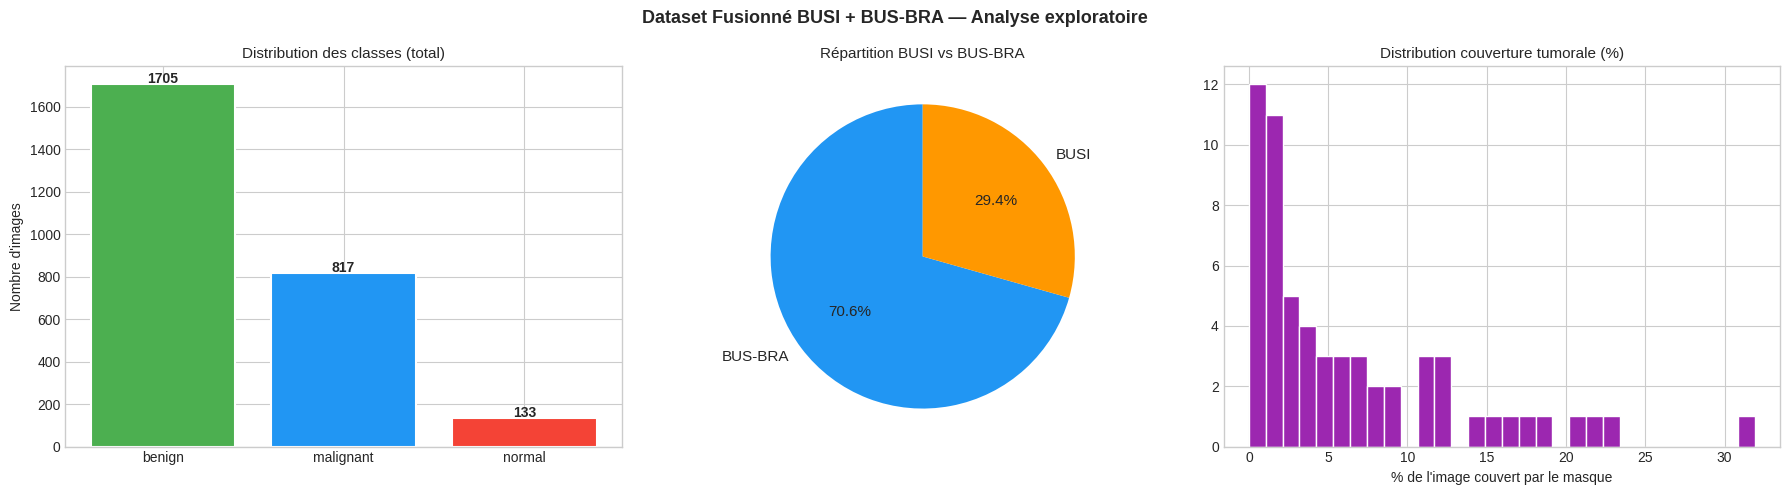


📊 Split final :
  Train: 1991 | {'benign': np.int64(1278), 'malignant': np.int64(613), 'normal': np.int64(100)}
  Val: 398 | {'benign': np.int64(256), 'malignant': np.int64(122), 'normal': np.int64(20)}
  Test: 266 | {'benign': np.int64(171), 'malignant': np.int64(82), 'normal': np.int64(13)}


In [7]:
# ─── 3c. Fusion BUSI + BUS-BRA ────────────────────────────────────────────────
if len(df_busbra) > 0:
    df = pd.concat([df_busi, df_busbra], ignore_index=True)
    print(f'\n✅ Dataset fusionné : {len(df)} images totales')
    print(f'   BUSI    : {len(df_busi)} images')
    print(f'   BUS-BRA : {len(df_busbra)} images')
else:
    df = df_busi.copy()
    print(f'\n⚠️  Dataset BUSI seul : {len(df)} images')

print(f'\nDistribution finale :')
print(df['label'].value_counts().to_string())

# ─── EDA fusionné ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dataset Fusionné BUSI + BUS-BRA — Analyse exploratoire', fontsize=13, fontweight='bold')

# Distribution par classe
counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#4CAF50','#2196F3','#F44336'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution des classes (total)', fontsize=11)
axes[0].set_ylabel('Nombre d\'images')
for i,(label,val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, val+5, str(val), ha='center', fontweight='bold')

# Distribution par source
if 'source' in df.columns and df['source'].nunique() > 1:
    src_counts = df['source'].value_counts()
    axes[1].pie(src_counts.values, labels=src_counts.index,
                autopct='%1.1f%%', colors=['#2196F3','#FF9800'],
                startangle=90, textprops={'fontsize':11})
    axes[1].set_title('Répartition BUSI vs BUS-BRA', fontsize=11)
else:
    axes[1].axis('off')
    axes[1].text(0.5, 0.5, 'BUSI uniquement', ha='center', va='center', fontsize=12)

# Couverture tumorale
coverages = []
for _, row in df.sample(min(200, len(df)), random_state=42).iterrows():
    if row['mask'] and os.path.exists(str(row['mask'])):
        msk = cv2.imread(row['mask'], cv2.IMREAD_GRAYSCALE)
        if msk is not None:
            coverages.append(msk.mean()/255*100)
axes[2].hist(coverages, bins=30, color='#9C27B0', edgecolor='white')
axes[2].set_title('Distribution couverture tumorale (%)', fontsize=11)
axes[2].set_xlabel('% de l\'image couvert par le masque')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_fusion.png', dpi=130, bbox_inches='tight')
plt.show()

# ─── Split stratifié ──────────────────────────────────────────────────────────
train_df, temp_df = train_test_split(df, test_size=CFG.VAL_SPLIT+CFG.TEST_SPLIT,
                                     stratify=df['label'], random_state=CFG.SEED)
val_df, test_df   = train_test_split(temp_df,
                                     test_size=CFG.TEST_SPLIT/(CFG.VAL_SPLIT+CFG.TEST_SPLIT),
                                     stratify=temp_df['label'], random_state=CFG.SEED)
print('\n📊 Split final :')
for name, d in [('Train',train_df),('Val',val_df),('Test',test_df)]:
    print(f'  {name}: {len(d)} | {dict(d["label"].value_counts())}')

## 🔄 4. Augmentations & Datasets PyTorch

In [8]:
def get_transforms(mode='train'):
    """
    Augmentations médicalement raisonnables pour échographies.
    NOUVEAU : ajout GaussNoise + RandomGamma pour robustesse multi-scanner BUS-BRA.
    """
    if mode == 'train':
        return A.Compose([
            A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.2),
            A.RandomRotate90(p=0.2),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.4),
            A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
            A.GaussianBlur(blur_limit=(3,5), p=0.2),
            A.GaussNoise(std_range=(0.02, 0.1), p=0.3),      # NOUVEAU : bruit écho multi-scanner
            A.RandomGamma(gamma_limit=(80,120), p=0.3), # NOUVEAU : variation luminosité scanner
            A.CLAHE(clip_limit=2.0, p=0.3),
            A.Normalize(mean=CFG.MEAN, std=CFG.STD),
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
            A.Normalize(mean=CFG.MEAN, std=CFG.STD),
            ToTensorV2(),
        ])

# ─── Dataset segmentation ─────────────────────────────────────────────────────
class BUSISegDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.cvtColor(cv2.imread(row['image']), cv2.COLOR_BGR2RGB)
        if row['mask'] and os.path.exists(str(row['mask'])):
            msk = cv2.imread(row['mask'], cv2.IMREAD_GRAYSCALE)
            msk = (msk > 127).astype(np.float32)
        else:
            msk = np.zeros((img.shape[0], img.shape[1]), dtype=np.float32)
        if self.transform:
            aug = self.transform(image=img, mask=msk)
            img = aug['image']
            msk = aug['mask'].unsqueeze(0)
        return img, msk

# ─── Dataset classification (3 classes) ──────────────────────────────────────
class BUSIClsDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.cvtColor(cv2.imread(row['image']), cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(image=img)['image']
        return img, torch.tensor(row['label_idx'], dtype=torch.long)

# ─── DataLoaders ──────────────────────────────────────────────────────────────
seg_train = BUSISegDataset(train_df, get_transforms('train'))
seg_val   = BUSISegDataset(val_df,   get_transforms('val'))
seg_test  = BUSISegDataset(test_df,  get_transforms('test'))

cls_train = BUSIClsDataset(train_df, get_transforms('train'))
cls_val   = BUSIClsDataset(val_df,   get_transforms('val'))
cls_test  = BUSIClsDataset(test_df,  get_transforms('test'))

loader_kwargs = dict(batch_size=CFG.BATCH_SIZE, num_workers=2, pin_memory=True)
seg_train_loader = DataLoader(seg_train, shuffle=True,  **loader_kwargs)
seg_val_loader   = DataLoader(seg_val,   shuffle=False, **loader_kwargs)
seg_test_loader  = DataLoader(seg_test,  shuffle=False, **loader_kwargs)
cls_train_loader = DataLoader(cls_train, shuffle=True,  **loader_kwargs)
cls_val_loader   = DataLoader(cls_val,   shuffle=False, **loader_kwargs)
cls_test_loader  = DataLoader(cls_test,  shuffle=False, **loader_kwargs)

print(f'✅ DataLoaders prêts ({len(df)} images fusionnées)')
print(f'   Seg  — Train: {len(seg_train_loader)} batches | Val: {len(seg_val_loader)}')
print(f'   Clf  — Train: {len(cls_train_loader)} batches | Val: {len(cls_val_loader)}')


✅ DataLoaders prêts (2655 images fusionnées)
   Seg  — Train: 125 batches | Val: 25
   Clf  — Train: 125 batches | Val: 25


## 🔬 5. Segmentation — ResNet34-UNet (BUSI + BUS-BRA)

> **Stratégie** : on construit un DataFrame de segmentation avec **uniquement les images qui ont un masque** dans les deux datasets.
> BUSI : 780 images avec masques. BUS-BRA : masques inclus si présents dans le zip.
> Loss combinée **BCE + Dice** pour meilleure gestion des petites lésions.

In [10]:
# ─── 5a. DataFrame segmentation — BUSI + BUS-BRA (masques uniquement) ──────────
records_seg = []

# ── BUSI ──────────────────────────────────────────────────────────────────────
BUSI_ONLY = '/content/dataset/Dataset_BUSI_with_GT'
for cat in ['normal', 'benign', 'malignant']:
    cat_dir = Path(BUSI_ONLY) / cat
    if not cat_dir.exists(): continue
    for img_path in sorted(cat_dir.glob('*.png')):
        if '_mask' in img_path.name: continue
        mask_path = cat_dir / img_path.name.replace('.png', '_mask.png')
        if not mask_path.exists(): continue
        records_seg.append({
            'image'    : str(img_path),
            'mask'     : str(mask_path),
            'label'    : cat,
            'label_idx': CFG.LABEL2IDX[cat],
            'source'   : 'BUSI'
        })

n_busi_seg = len(records_seg)
print(f'✅ BUSI segmentation : {n_busi_seg} images avec masques')

# ── BUS-BRA ───────────────────────────────────────────────────────────────────
# Structure : Images/bus_XXXX-x.png  →  Masks/mask_XXXX-x.png
BUSBRA_IMGS_DIR  = '/content/busbra/BUSBRA/Images'
BUSBRA_MASKS_DIR = '/content/busbra/BUSBRA/Masks'

if os.path.exists(BUSBRA_IMGS_DIR) and len(df_busbra) > 0:
    label_map_busbra = {row['image']: row['label'] for _, row in df_busbra.iterrows()}

    for img_file in sorted(os.listdir(BUSBRA_IMGS_DIR)):
        if not img_file.endswith('.png'): continue
        img_path  = os.path.join(BUSBRA_IMGS_DIR, img_file)

        # bus_0061-r.png → mask_0061-r.png
        mask_name = img_file.replace('bus_', 'mask_')
        mask_path = os.path.join(BUSBRA_MASKS_DIR, mask_name)

        if not os.path.exists(mask_path): continue

        label = label_map_busbra.get(img_path, None)
        if label is None: continue

        records_seg.append({
            'image'    : img_path,
            'mask'     : mask_path,
            'label'    : label,
            'label_idx': CFG.LABEL2IDX[label],
            'source'   : 'BUS-BRA'
        })

n_busbra_seg = len(records_seg) - n_busi_seg
print(f'✅ BUS-BRA segmentation : {n_busbra_seg} images avec masques')

df_seg = pd.DataFrame(records_seg)
print(f'\n📊 Total segmentation : {len(df_seg)} images')
print(df_seg['label'].value_counts().to_string())
print('\nPar source :')
print(df_seg.groupby('source')['label'].count().to_string())

# ─── Split stratifié ──────────────────────────────────────────────────────────
train_seg_df, temp_seg = train_test_split(df_seg, test_size=0.25,
                                          stratify=df_seg['label'], random_state=CFG.SEED)
val_seg_df, test_seg_df = train_test_split(temp_seg, test_size=0.4,
                                           stratify=temp_seg['label'], random_state=CFG.SEED)
for name, d in [('Train', train_seg_df), ('Val', val_seg_df), ('Test', test_seg_df)]:
    print(f'  {name}: {len(d)}')

# ─── DataLoaders segmentation ─────────────────────────────────────────────────
seg_train_loader = DataLoader(BUSISegDataset(train_seg_df, get_transforms('train')),
                               batch_size=CFG.BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
seg_val_loader   = DataLoader(BUSISegDataset(val_seg_df,   get_transforms('val')),
                               batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
seg_test_loader  = DataLoader(BUSISegDataset(test_seg_df,  get_transforms('test')),
                               batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print('\n✅ DataLoaders segmentation prêts')
print(f'   Train: {len(seg_train_loader)} batches | Val: {len(seg_val_loader)} | Test: {len(seg_test_loader)}')

✅ BUSI segmentation : 780 images avec masques
✅ BUS-BRA segmentation : 1875 images avec masques

📊 Total segmentation : 2655 images
label
benign       1705
malignant     817
normal        133

Par source :
source
BUS-BRA    1875
BUSI        780
  Train: 1991
  Val: 398
  Test: 266

✅ DataLoaders segmentation prêts
   Train: 125 batches | Val: 25 | Test: 17


In [11]:
# ─── 5b. Modèle ResNet34-UNet + Loss BCE+Dice + Métriques ───────────────────────
seg_model = smp.Unet(
    encoder_name    = 'resnet34',
    encoder_weights = 'imagenet',
    in_channels     = 3,
    classes         = 1,
).to(CFG.DEVICE)

class BCEDiceLoss(nn.Module):
    """
    Combinaison BCE + Dice Loss.
    - BCE  : stable sur les pixels fond (majoritaires)
    - Dice : optimise directement le chevauchement masque prédit / réel
    """
    def __init__(self, bce_w=0.5, dice_w=0.5, smooth=1e-6):
        super().__init__()
        self.bce_w  = bce_w
        self.dice_w = dice_w
        self.smooth = smooth
        self.bce    = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce_loss  = self.bce(logits, targets)
        probs     = torch.sigmoid(logits)
        inter     = (probs * targets).sum(dim=(2, 3))
        union     = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice_loss = 1 - (2 * inter + self.smooth) / (union + self.smooth)
        return self.bce_w * bce_loss + self.dice_w * dice_loss.mean()

def seg_metrics(pred_logits, targets, threshold=0.5):
    preds = (torch.sigmoid(pred_logits) > threshold).float()
    inter = (preds * targets).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
    dice  = ((2 * inter + 1e-6) / (union + 1e-6)).mean().item()
    iou   = ((inter + 1e-6) / (union - inter + 1e-6)).mean().item()
    prec  = ((inter + 1e-6) / (preds.sum(dim=(2, 3)) + 1e-6)).mean().item()
    rec   = ((inter + 1e-6) / (targets.sum(dim=(2, 3)) + 1e-6)).mean().item()
    return {'dice': dice, 'iou': iou, 'precision': prec, 'recall': rec}

seg_criterion = BCEDiceLoss(bce_w=CFG.BCE_WEIGHT, dice_w=CFG.DICE_WEIGHT)
seg_optimizer = torch.optim.AdamW(seg_model.parameters(), lr=CFG.LR_SEG, weight_decay=1e-5)
seg_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(seg_optimizer, T_0=10, T_mult=2)

n_params = sum(p.numel() for p in seg_model.parameters() if p.requires_grad)
print(f'✅ ResNet34-UNet prêt | {n_params:,} paramètres')
print(f'   Loss : BCE({CFG.BCE_WEIGHT}) + Dice({CFG.DICE_WEIGHT})')
print(f'   Dataset segmentation : {len(df_seg)} images ({n_busi_seg} BUSI + {n_busbra_seg} BUS-BRA)')

Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to /root/.cache/torch/hub/checkpoints/resnet34-333f7ec4.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 197MB/s]


✅ ResNet34-UNet prêt | 24,436,369 paramètres
   Loss : BCE(0.5) + Dice(0.5)
   Dataset segmentation : 2655 images (780 BUSI + 1875 BUS-BRA)


In [12]:
# ─── Upgrade architecture + loss pour viser 0.90+ ────────────────────────────
import segmentation_models_pytorch as smp

# 1. Encodeur plus puissant : ResNet50 au lieu de ResNet34
# 2. Loss Dice + Focal (meilleure que BCE sur données déséquilibrées)
# 3. LR warmup + CosineAnnealing

seg_model = smp.Unet(
    encoder_name    = 'resnet50',       # plus puissant que resnet34
    encoder_weights = 'imagenet',
    in_channels     = 3,
    classes         = 1,
    decoder_attention_type = 'scse',    # attention mécanisme sur le décodeur
).to(CFG.DEVICE)

class DiceFocalLoss(nn.Module):
    """
    Dice + Focal Loss — meilleure combinaison pour segmentation médicale.
    Focal : pénalise plus fortement les pixels mal classés (petites lésions).
    """
    def __init__(self, dice_w=0.6, focal_w=0.4, gamma=2.0, smooth=1e-6):
        super().__init__()
        self.dice_w  = dice_w
        self.focal_w = focal_w
        self.gamma   = gamma
        self.smooth  = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        # Dice Loss
        inter     = (probs * targets).sum(dim=(2, 3))
        union     = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice_loss = 1 - (2 * inter + self.smooth) / (union + self.smooth)
        dice_loss = dice_loss.mean()

        # Focal Loss
        bce        = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        focal_w_map = (1 - probs.detach()) ** self.gamma
        focal_loss  = (focal_w_map * bce).mean()

        return self.dice_w * dice_loss + self.focal_w * focal_loss

seg_criterion = DiceFocalLoss(dice_w=0.6, focal_w=0.4, gamma=2.0)

# Optimizer avec warmup
seg_optimizer = torch.optim.AdamW(seg_model.parameters(), lr=1e-4, weight_decay=1e-4)

# Scheduler : warmup 3 epochs puis cosine
def warmup_cosine(epoch, warmup=3, total=60):
    if epoch < warmup:
        return (epoch + 1) / warmup
    progress = (epoch - warmup) / (total - warmup)
    return 0.5 * (1 + np.cos(np.pi * progress))

seg_scheduler = torch.optim.lr_scheduler.LambdaLR(seg_optimizer,
                    lr_lambda=lambda e: warmup_cosine(e, warmup=3, total=60))

SEG_SAVE_V2   = os.path.join(PROJECT_DIR, 'BEST_ResNet50_UNet_SCSE.pth')
best_seg_dice = 0.0
patience, patience_ctr = 15, 0

n_params = sum(p.numel() for p in seg_model.parameters() if p.requires_grad)
print(f'✅ ResNet50-UNet + SCSE attention | {n_params/1e6:.1f}M paramètres')
print(f'   Loss : Dice(0.6) + Focal(0.4) gamma=2')
print(f'   LR   : warmup 3 epochs → cosine decay')
print(f'   Patience : 15 epochs')
print('-' * 60)

for epoch in range(1, 61):
    # ── Train ──────────────────────────────────────────────────────────────────
    seg_model.train(); train_loss = 0.0
    for imgs, masks in tqdm(seg_train_loader, desc=f'Epoch {epoch:02d}/60', leave=False):
        imgs, masks = imgs.to(CFG.DEVICE), masks.to(CFG.DEVICE)
        seg_optimizer.zero_grad()
        loss = seg_criterion(seg_model(imgs), masks)
        loss.backward()
        nn.utils.clip_grad_norm_(seg_model.parameters(), 1.0)
        seg_optimizer.step()
        train_loss += loss.item()
    train_loss /= len(seg_train_loader)
    seg_scheduler.step()

    # ── Val ────────────────────────────────────────────────────────────────────
    seg_model.eval(); val_loss = 0.0
    val_m = {'dice': 0, 'iou': 0, 'precision': 0, 'recall': 0}
    with torch.no_grad():
        for imgs, masks in seg_val_loader:
            imgs, masks = imgs.to(CFG.DEVICE), masks.to(CFG.DEVICE)
            logits = seg_model(imgs)
            val_loss += seg_criterion(logits, masks).item()
            m = seg_metrics(logits, masks)
            for k in val_m: val_m[k] += m[k]
    val_loss /= len(seg_val_loader)
    for k in val_m: val_m[k] /= len(seg_val_loader)

    lr_now = seg_optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch:02d} | Loss train={train_loss:.4f} val={val_loss:.4f} '
          f'| Dice={val_m["dice"]:.4f} IoU={val_m["iou"]:.4f} | LR={lr_now:.2e}')

    if val_m['dice'] > best_seg_dice:
        best_seg_dice = val_m['dice']
        torch.save(seg_model.state_dict(), SEG_SAVE_V2)
        print(f'   ✅ Nouveau meilleur Dice : {best_seg_dice:.4f} — sauvegardé !')
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f'   ⏹ Early stopping epoch {epoch}')
            break

seg_model.load_state_dict(torch.load(SEG_SAVE_V2, map_location=CFG.DEVICE))
print(f'\n✅ Meilleur Dice final : {best_seg_dice:.4f}')
SEG_SAVE = SEG_SAVE_V2  # mettre à jour le chemin pour la suite du pipeline

Downloading: "https://download.pytorch.org/models/resnet50-19c8e357.pth" to /root/.cache/torch/hub/checkpoints/resnet50-19c8e357.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 231MB/s]


✅ ResNet50-UNet + SCSE attention | 33.8M paramètres
   Loss : Dice(0.6) + Focal(0.4) gamma=2
   LR   : warmup 3 epochs → cosine decay
   Patience : 15 epochs
------------------------------------------------------------


KeyboardInterrupt: 

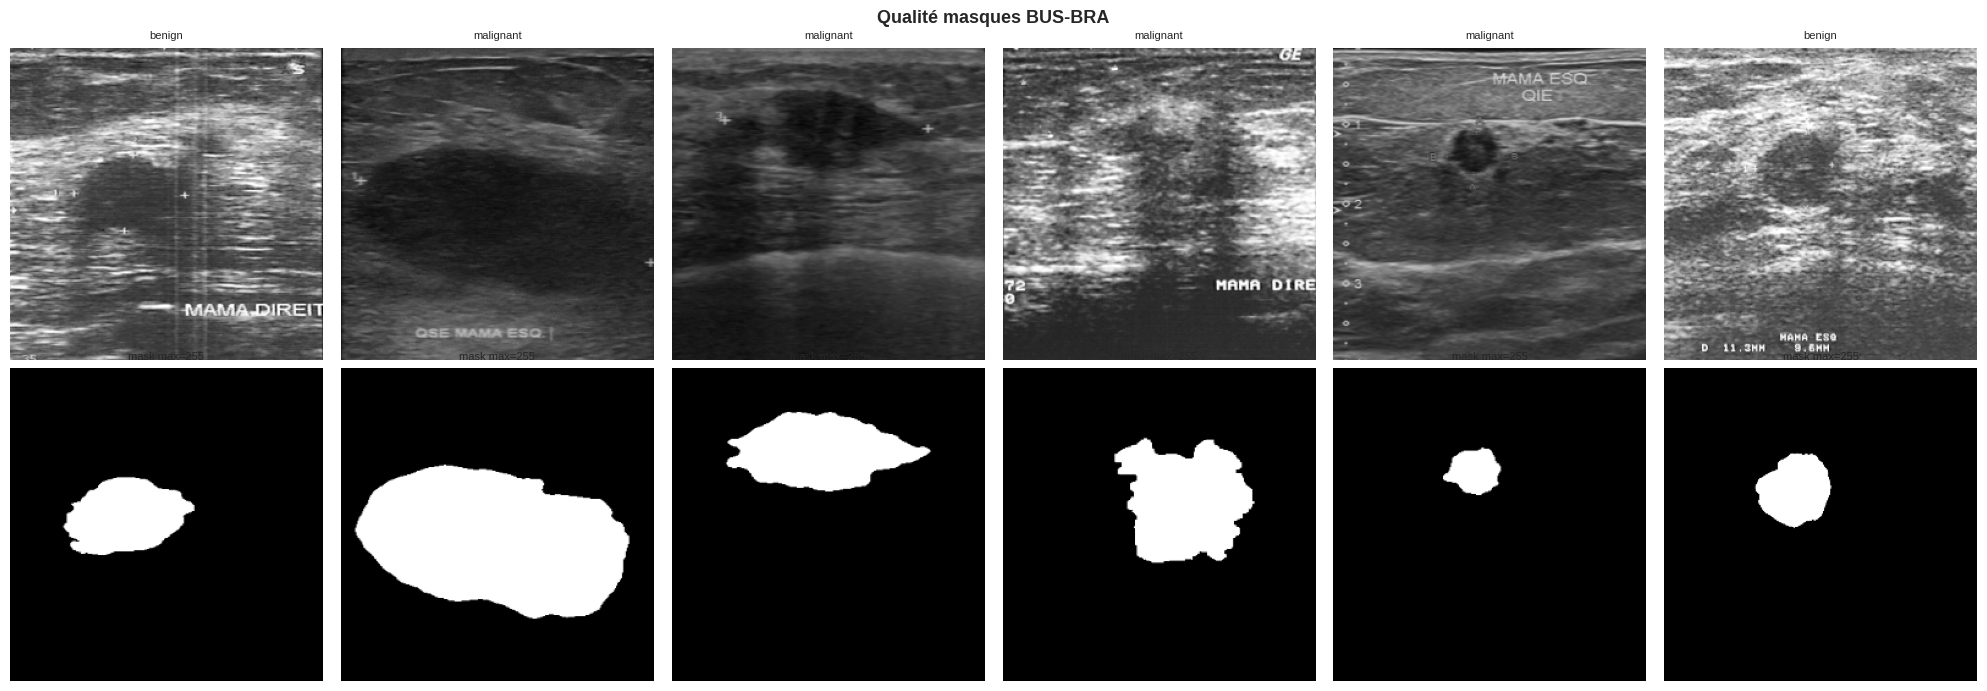

Stats masques BUS-BRA :
  Couverture moyenne : 8.7%
  Masques vides (=0) : 0
  Total BUS-BRA      : 1875


In [13]:
# Vérifier qualité visuelle des masques BUS-BRA
import random
busbra_samples = df_seg[df_seg['source'] == 'BUS-BRA'].sample(6, random_state=42)

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
fig.suptitle('Qualité masques BUS-BRA', fontsize=13, fontweight='bold')

for i, (_, row) in enumerate(busbra_samples.iterrows()):
    img = cv2.cvtColor(cv2.imread(row['image']), cv2.COLOR_BGR2RGB)
    msk = cv2.imread(row['mask'], cv2.IMREAD_GRAYSCALE)
    axes[0, i].imshow(cv2.resize(img, (256,256))); axes[0, i].axis('off')
    axes[0, i].set_title(row['label'], fontsize=8)
    axes[1, i].imshow(cv2.resize(msk, (256,256)), cmap='gray'); axes[1, i].axis('off')
    axes[1, i].set_title(f'mask max={msk.max()}', fontsize=8)

plt.tight_layout()
plt.show()

# Stats masques
print("Stats masques BUS-BRA :")
coverages = []
for _, row in df_seg[df_seg['source']=='BUS-BRA'].iterrows():
    msk = cv2.imread(row['mask'], cv2.IMREAD_GRAYSCALE)
    if msk is not None:
        coverages.append(msk.mean()/255*100)
print(f"  Couverture moyenne : {np.mean(coverages):.1f}%")
print(f"  Masques vides (=0) : {sum(1 for c in coverages if c < 0.1)}")
print(f"  Total BUS-BRA      : {len(coverages)}")


In [14]:
print("=== Composition df_seg ===")
print(df_seg.groupby('source').size())

print("\n=== Couverture moyenne par source ===")
for source in df_seg['source'].unique():
    coverages = []
    for _, row in df_seg[df_seg['source']==source].iterrows():
        msk = cv2.imread(row['mask'], cv2.IMREAD_GRAYSCALE)
        if msk is not None:
            coverages.append(msk.mean()/255*100)
    print(f"  {source} : {len(coverages)} images | couverture moy={np.mean(coverages):.1f}%")

=== Composition df_seg ===
source
BUS-BRA    1875
BUSI        780
dtype: int64

=== Couverture moyenne par source ===
  BUSI : 780 images | couverture moy=7.7%
  BUS-BRA : 1875 images | couverture moy=8.7%


In [ ]:
# ─── Architecture Swin-UNet / SegFormer pour viser 0.90+ ─────────────────────
import segmentation_models_pytorch as smp

# MIT-B2 = encodeur Transformer (SegFormer) — état de l'art segmentation médicale
seg_model = smp.Unet(
    encoder_name    = 'mit_b2',         # Transformer encoder au lieu de CNN
    encoder_weights = 'imagenet',
    in_channels     = 3,
    classes         = 1,
    decoder_attention_type = 'scse',
).to(CFG.DEVICE)

# Augmentations renforcées spécifiques petites lésions
def get_transforms_seg_v2(mode='train'):
    if mode == 'train':
        return A.Compose([
            A.Resize(320, 320),               # plus grand = plus de détails
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomRotate90(p=0.3),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15,
                               rotate_limit=15, p=0.5),
            A.ElasticTransform(p=0.3),        # déformation élastique médicale
            A.GridDistortion(p=0.2),
            A.RandomBrightnessContrast(p=0.4),
            A.CLAHE(clip_limit=3.0, p=0.4),
            A.GaussNoise(std_range=(0.02, 0.08), p=0.3),
            A.Normalize(mean=CFG.MEAN, std=CFG.STD),
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Resize(320, 320),
            A.Normalize(mean=CFG.MEAN, std=CFG.STD),
            ToTensorV2(),
        ])

# Recréer les DataLoaders avec la nouvelle taille
seg_train_loader_v2 = DataLoader(
    BUSISegDataset(train_seg_df, get_transforms_seg_v2('train')),
    batch_size=8, shuffle=True, num_workers=2, pin_memory=True)  # batch plus petit car 320x320
seg_val_loader_v2 = DataLoader(
    BUSISegDataset(val_seg_df, get_transforms_seg_v2('val')),
    batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
seg_test_loader_v2 = DataLoader(
    BUSISegDataset(test_seg_df, get_transforms_seg_v2('test')),
    batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

seg_criterion = DiceFocalLoss(dice_w=0.6, focal_w=0.4, gamma=2.0)
seg_optimizer = torch.optim.AdamW(seg_model.parameters(), lr=6e-5, weight_decay=1e-4)
seg_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(seg_optimizer, T_max=50, eta_min=1e-7)

SEG_SAVE_V3   = os.path.join(PROJECT_DIR, 'BEST_MiT_B2_UNet.pth')
best_seg_dice = 0.0
patience, patience_ctr = 15, 0

n_params = sum(p.numel() for p in seg_model.parameters() if p.requires_grad)
print(f'✅ MiT-B2 UNet (Transformer) | {n_params/1e6:.1f}M paramètres')
print(f'   Image size : 320×320')
print(f'   Loss : Dice(0.6) + Focal(0.4)')
print('-' * 60)

for epoch in range(1, 61):
    seg_model.train(); train_loss = 0.0
    for imgs, masks in tqdm(seg_train_loader_v2, desc=f'Epoch {epoch:02d}/60', leave=False):
        imgs, masks = imgs.to(CFG.DEVICE), masks.to(CFG.DEVICE)
        seg_optimizer.zero_grad()
        loss = seg_criterion(seg_model(imgs), masks)
        loss.backward()
        nn.utils.clip_grad_norm_(seg_model.parameters(), 1.0)
        seg_optimizer.step()
        train_loss += loss.item()
    train_loss /= len(seg_train_loader_v2)
    seg_scheduler.step()

    seg_model.eval(); val_loss = 0.0
    val_m = {'dice': 0, 'iou': 0, 'precision': 0, 'recall': 0}
    with torch.no_grad():
        for imgs, masks in seg_val_loader_v2:
            imgs, masks = imgs.to(CFG.DEVICE), masks.to(CFG.DEVICE)
            logits = seg_model(imgs)
            val_loss += seg_criterion(logits, masks).item()
            m = seg_metrics(logits, masks)
            for k in val_m: val_m[k] += m[k]
    val_loss /= len(seg_val_loader_v2)
    for k in val_m: val_m[k] /= len(seg_val_loader_v2)

    print(f'Epoch {epoch:02d} | Loss train={train_loss:.4f} val={val_loss:.4f} '
          f'| Dice={val_m["dice"]:.4f} IoU={val_m["iou"]:.4f}')

    if val_m['dice'] > best_seg_dice:
        best_seg_dice = val_m['dice']
        torch.save(seg_model.state_dict(), SEG_SAVE_V3)
        print(f'   ✅ Nouveau meilleur Dice : {best_seg_dice:.4f} — sauvegardé !')
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f'   ⏹ Early stopping epoch {epoch}')
            break

seg_model.load_state_dict(torch.load(SEG_SAVE_V3, map_location=CFG.DEVICE))
SEG_SAVE = SEG_SAVE_V3
print(f'\n✅ Meilleur Dice final : {best_seg_dice:.4f}')

In [ ]:
# Vérification visuelle BUSI + BUS-BRA côte à côte
fig, axes = plt.subplots(4, 6, figsize=(22, 14))
fig.suptitle('Vérification visuelle masques — BUSI vs BUS-BRA', fontsize=13, fontweight='bold')

for col, source in enumerate(['BUSI', 'BUS-BRA']):
    subset = df_seg[df_seg['source'] == source].sample(6, random_state=42).reset_index(drop=True)
    for i, (_, row) in enumerate(subset.iterrows()):
        img = cv2.cvtColor(cv2.imread(row['image']), cv2.COLOR_BGR2RGB)
        msk = cv2.imread(row['mask'], cv2.IMREAD_GRAYSCALE)
        img_r = cv2.resize(img, (256, 256))
        msk_r = cv2.resize(msk, (256, 256))

        ax_img  = axes[i // 3 * 2,     col * 3 + i % 3]
        ax_mask = axes[i // 3 * 2 + 1, col * 3 + i % 3]

        ax_img.imshow(img_r); ax_img.axis('off')
        ax_img.set_title(f'{source}\n{row["label"]}', fontsize=7)
        ax_mask.imshow(msk_r, cmap='gray', vmin=0, vmax=255); ax_mask.axis('off')
        ax_mask.set_title(f'max={msk.max()} cov={msk.mean()/255*100:.1f}%', fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
# ─── 5d. Courbes d'entraînement segmentation ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Segmentation ResNet34-UNet — Courbes entraînement (BUSI + BUS-BRA)', fontsize=13, fontweight='bold')

epochs_ran = range(1, len(seg_history['train_loss']) + 1)
axes[0].plot(epochs_ran, seg_history['train_loss'], label='Train Loss', color='#E53935', linewidth=2)
axes[0].plot(epochs_ran, seg_history['val_loss'],   label='Val Loss',   color='#1E88E5', linewidth=2)
axes[0].set_title('BCE + Dice Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(epochs_ran, seg_history['val_dice'], label='Dice', color='#43A047', linewidth=2)
axes[1].plot(epochs_ran, seg_history['val_iou'],  label='IoU',  color='#FB8C00', linewidth=2)
axes[1].set_title('Métriques validation'); axes[1].legend(); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/seg_training_curves.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# ─── 5e. Courbes d'entraînement ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MiT-B2 UNet — Courbes entraînement (BUSI + BUS-BRA)', fontsize=13, fontweight='bold')

epochs_ran = range(1, len(seg_history['train_loss']) + 1)
axes[0].plot(epochs_ran, seg_history['train_loss'], label='Train', color='#E53935', linewidth=2)
axes[0].plot(epochs_ran, seg_history['val_loss'],   label='Val',   color='#1E88E5', linewidth=2)
axes[0].set_title('Dice + Focal Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(epochs_ran, seg_history['val_dice'], label='Dice', color='#43A047', linewidth=2)
axes[1].plot(epochs_ran, seg_history['val_iou'],  label='IoU',  color='#FB8C00', linewidth=2)
axes[1].axhline(y=best_seg_dice, color='#43A047', linestyle='--', alpha=0.5,
                label=f'Best Dice={best_seg_dice:.4f}')
axes[1].set_title('Métriques validation'); axes[1].legend(); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/seg_training_curves.png', dpi=130, bbox_inches='tight')
plt.show()


In [ ]:
# ─── 5e. Évaluation test set + visualisation ─────────────────────────────────
def denorm(tensor):
    mean = torch.tensor(CFG.MEAN).view(3, 1, 1)
    std  = torch.tensor(CFG.STD).view(3, 1, 1)
    return torch.clamp(tensor.cpu() * std + mean, 0, 1).permute(1, 2, 0).numpy()

def postprocess_mask(pred_np, threshold=0.5, min_area=100):
    binary  = (pred_np > threshold).astype(np.uint8)
    kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN,  kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)
    nb_comp, labels, stats, _ = cv2.connectedComponentsWithStats(cleaned)
    final = np.zeros_like(cleaned)
    for i in range(1, nb_comp):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            final[labels == i] = 1
    return final

# ── Métriques test set ────────────────────────────────────────────────────────
seg_model.eval()
test_m = {'dice': 0, 'iou': 0, 'precision': 0, 'recall': 0}
with torch.no_grad():
    for imgs, masks in seg_test_loader:
        imgs, masks = imgs.to(CFG.DEVICE), masks.to(CFG.DEVICE)
        m = seg_metrics(seg_model(imgs), masks)
        for k in test_m: test_m[k] += m[k]
for k in test_m: test_m[k] /= len(seg_test_loader)
seg_metrics_final = test_m

print('📋 Métriques segmentation — Test set :')
for k, v in seg_metrics_final.items():
    print(f'   {k:12s}: {v:.4f}')

# ── Visualisation 4 exemples du test set ──────────────────────────────────────
# Prendre uniquement des images BUSI pour la visualisation (masques garantis)
test_busi_df = test_seg_df[test_seg_df['source'] == 'BUSI'] if 'source' in test_seg_df.columns else test_seg_df
sample_df    = test_busi_df.sample(min(4, len(test_busi_df)), random_state=42)

sample_loader = DataLoader(
    BUSISegDataset(sample_df, get_transforms('test')),
    batch_size=len(sample_df), shuffle=False
)
imgs_v, masks_v = next(iter(sample_loader))

seg_model.eval()
with torch.no_grad():
    preds_v = torch.sigmoid(seg_model(imgs_v.to(CFG.DEVICE))).cpu()

print(f'\n[DEBUG] pred min={preds_v.min():.4f} max={preds_v.max():.4f}')
print(f'[DEBUG] GT pixels actifs : {(masks_v > 0.5).float().mean()*100:.2f}%')

n_show = len(sample_df)
fig, axes = plt.subplots(n_show, 4, figsize=(18, 4.5 * n_show))
fig.suptitle('Segmentation ResNet34-UNet (BUSI + BUS-BRA) — Test set', fontsize=13, fontweight='bold')
if n_show == 1: axes = axes[np.newaxis, :]

col_titles = ['Image originale', 'Masque GT', 'Prédiction (sigmoid)', 'Post-traitement']
for j, t in enumerate(col_titles):
    axes[0, j].set_title(t, fontweight='bold', fontsize=10)

for i in range(n_show):
    img_np  = denorm(imgs_v[i])
    mask_np = masks_v[i, 0].numpy()
    pred_np = preds_v[i, 0].numpy()
    clean   = postprocess_mask(pred_np)

    axes[i, 0].imshow(img_np);                               axes[i, 0].axis('off')
    axes[i, 1].imshow(mask_np, cmap='gray', vmin=0, vmax=1); axes[i, 1].axis('off')
    axes[i, 2].imshow(pred_np, cmap='hot',  vmin=0, vmax=1)
    axes[i, 2].set_title(f'max={pred_np.max():.3f}', fontsize=7); axes[i, 2].axis('off')
    axes[i, 3].imshow(img_np)
    if clean.sum() > 0:
        rgba = np.zeros((*clean.shape, 4), dtype=np.float32)
        rgba[clean > 0] = [1.0, 0.1, 0.1, 0.55]
        axes[i, 3].imshow(rgba)
    axes[i, 3].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/seg_predictions.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# ─── 5f. Évaluation test set + visualisation ─────────────────────────────────
def denorm(tensor):
    mean = torch.tensor(CFG.MEAN).view(3, 1, 1)
    std  = torch.tensor(CFG.STD).view(3, 1, 1)
    return torch.clamp(tensor.cpu() * std + mean, 0, 1).permute(1, 2, 0).numpy()

def postprocess_mask(pred_np, threshold=0.5, min_area=100):
    binary  = (pred_np > threshold).astype(np.uint8)
    kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN,  kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)
    nb_comp, labels, stats, _ = cv2.connectedComponentsWithStats(cleaned)
    final = np.zeros_like(cleaned)
    for i in range(1, nb_comp):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            final[labels == i] = 1
    return final

def get_transforms_seg(mode='train'):
    if mode == 'train':
        return A.Compose([
            A.Resize(320, 320),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomRotate90(p=0.3),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15, rotate_limit=15, p=0.5),
            A.ElasticTransform(p=0.3),
            A.GridDistortion(p=0.2),
            A.RandomBrightnessContrast(p=0.4),
            A.CLAHE(clip_limit=3.0, p=0.4),
            A.GaussNoise(std_range=(0.02, 0.08), p=0.3),
            A.Normalize(mean=CFG.MEAN, std=CFG.STD),
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Resize(320, 320),
            A.Normalize(mean=CFG.MEAN, std=CFG.STD),
            ToTensorV2(),
        ])

# ── Métriques test set ────────────────────────────────────────────────────────
seg_model.eval()
test_m = {'dice': 0, 'iou': 0, 'precision': 0, 'recall': 0}
with torch.no_grad():
    for imgs, masks in seg_test_loader:
        imgs, masks = imgs.to(CFG.DEVICE), masks.to(CFG.DEVICE)
        m = seg_metrics(seg_model(imgs), masks)
        for k in test_m: test_m[k] += m[k]
for k in test_m: test_m[k] /= len(seg_test_loader)
seg_metrics_final = test_m

print('📋 Métriques segmentation — Test set :')
for k, v in seg_metrics_final.items():
    print(f'   {k:12s}: {v:.4f}')

# ── Visualisation 4 exemples BUSI ─────────────────────────────────────────────
test_busi = test_seg_df[test_seg_df['source'] == 'BUSI'] if 'source' in test_seg_df.columns else test_seg_df
sample_df  = test_busi.sample(min(4, len(test_busi)), random_state=42)

sample_loader = DataLoader(BUSISegDataset(sample_df, get_transforms_seg('test')),
                           batch_size=len(sample_df), shuffle=False)
imgs_v, masks_v = next(iter(sample_loader))

seg_model.eval()
with torch.no_grad():
    preds_v = torch.sigmoid(seg_model(imgs_v.to(CFG.DEVICE))).cpu()

print(f'\n[DEBUG] pred min={preds_v.min():.4f} max={preds_v.max():.4f}')
print(f'[DEBUG] GT pixels actifs : {(masks_v > 0.5).float().mean()*100:.2f}%')

n_show = len(sample_df)
fig, axes = plt.subplots(n_show, 4, figsize=(18, 4.5 * n_show))
fig.suptitle(f'Segmentation MiT-B2 UNet — Test set (Dice={seg_metrics_final["dice"]:.4f})',
             fontsize=13, fontweight='bold')
if n_show == 1: axes = axes[np.newaxis, :]

for j, t in enumerate(['Image originale', 'Masque GT', 'Prédiction (sigmoid)', 'Post-traitement']):
    axes[0, j].set_title(t, fontweight='bold', fontsize=10)

for i in range(n_show):
    img_np  = denorm(imgs_v[i])
    mask_np = masks_v[i, 0].numpy()
    pred_np = preds_v[i, 0].numpy()
    clean   = postprocess_mask(pred_np)

    axes[i, 0].imshow(img_np);                                axes[i, 0].axis('off')
    axes[i, 1].imshow(mask_np, cmap='gray', vmin=0, vmax=1);  axes[i, 1].axis('off')
    axes[i, 2].imshow(pred_np, cmap='hot',  vmin=0, vmax=1)
    axes[i, 2].set_title(f'max={pred_np.max():.3f}', fontsize=7); axes[i, 2].axis('off')
    axes[i, 3].imshow(img_np)
    if clean.sum() > 0:
        rgba = np.zeros((*clean.shape, 4), dtype=np.float32)
        rgba[clean > 0] = [1.0, 0.1, 0.1, 0.55]
        axes[i, 3].imshow(rgba)
    axes[i, 3].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/seg_predictions.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# ─── 5f. Test sur image personnalisée (image.png + mask.png du Drive) ──────────
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  Place image.png et mask.png dans ton dossier Drive MonProjetcancer     ║
# ║  Le masque doit être en niveaux de gris (blanc = tumeur, noir = fond)   ║
# ╚══════════════════════════════════════════════════════════════════════════╝

CUSTOM_IMG_PATH  = os.path.join(PROJECT_DIR, 'image.png')
CUSTOM_MASK_PATH = os.path.join(PROJECT_DIR, 'mask.png')

if not os.path.exists(CUSTOM_IMG_PATH):
    print(f'⚠️  image.png introuvable dans {PROJECT_DIR}')
    print('   Place ton image dans ce dossier et relance cette cellule.')
else:
    # ── Chargement ────────────────────────────────────────────────────────────
    img_bgr  = cv2.imread(CUSTOM_IMG_PATH)
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    has_mask = os.path.exists(CUSTOM_MASK_PATH)
    if has_mask:
        gt_bgr  = cv2.imread(CUSTOM_MASK_PATH, cv2.IMREAD_GRAYSCALE)
        gt_mask = cv2.resize(gt_bgr, (CFG.IMG_SIZE, CFG.IMG_SIZE))
        gt_mask = (gt_mask > 127).astype(np.float32)
    else:
        print('⚠️  mask.png non trouvé — affichage sans GT')
        gt_mask = None

    # ── Préprocessing & inférence ─────────────────────────────────────────────
    tf_val      = get_transforms('val')
    tensor      = tf_val(image=img_rgb)['image'].unsqueeze(0).to(CFG.DEVICE)
    img_display = cv2.resize(img_rgb, (CFG.IMG_SIZE, CFG.IMG_SIZE)).astype(np.float32) / 255.0

    seg_model.eval()
    with torch.no_grad():
        pred_raw = torch.sigmoid(seg_model(tensor))[0, 0].cpu().numpy()
    pred_clean = postprocess_mask(pred_raw)

    # ── Métriques si masque disponible ───────────────────────────────────────
    if gt_mask is not None:
        p = (pred_raw > 0.5).astype(np.float32).ravel()
        t = gt_mask.ravel()
        tp = (p * t).sum(); fp = (p * (1 - t)).sum(); fn = ((1 - p) * t).sum()
        dice_custom = round((2 * tp + 1e-6) / (2 * tp + fp + fn + 1e-6), 4)
        iou_custom  = round((tp + 1e-6) / (tp + fp + fn + 1e-6), 4)
        print(f'📊 Métriques sur image personnalisée :')
        print(f'   Dice : {dice_custom:.4f}')
        print(f'   IoU  : {iou_custom:.4f}')

    # ── Visualisation ─────────────────────────────────────────────────────────
    n_cols = 4 if has_mask else 3
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 6))
    fig.suptitle('Test sur image personnalisée — ResNet34-UNet', fontsize=13, fontweight='bold')

    axes[0].imshow(img_display)
    axes[0].set_title('Image originale', fontweight='bold'); axes[0].axis('off')

    if has_mask:
        axes[1].imshow(gt_mask, cmap='gray', vmin=0, vmax=1)
        axes[1].set_title('Masque réel (GT)', fontweight='bold', color='green'); axes[1].axis('off')

        axes[2].imshow(pred_raw, cmap='hot', vmin=0, vmax=1)
        axes[2].set_title(f'Prédiction IA (max={pred_raw.max():.3f})', fontweight='bold'); axes[2].axis('off')

        # Comparaison côte à côte : GT vs IA
        axes[3].imshow(img_display)
        # GT en vert
        gt_rgba = np.zeros((*gt_mask.shape, 4), dtype=np.float32)
        gt_rgba[gt_mask > 0] = [0.0, 1.0, 0.0, 0.45]
        axes[3].imshow(gt_rgba)
        # Prédiction en rouge
        pred_rgba = np.zeros((*pred_clean.shape, 4), dtype=np.float32)
        pred_rgba[pred_clean > 0] = [1.0, 0.0, 0.0, 0.35]
        axes[3].imshow(pred_rgba)
        axes[3].set_title('Vert=GT  |  Rouge=IA', fontweight='bold'); axes[3].axis('off')

        # Légende
        from matplotlib.patches import Patch
        legend = [Patch(color='green', alpha=0.6, label='Masque réel'),
                  Patch(color='red',   alpha=0.5, label='Prédiction IA')]
        axes[3].legend(handles=legend, loc='lower right', fontsize=9)

        if gt_mask is not None:
            axes[3].set_xlabel(f'Dice={dice_custom:.4f} | IoU={iou_custom:.4f}', fontsize=10)
    else:
        axes[1].imshow(pred_raw, cmap='hot', vmin=0, vmax=1)
        axes[1].set_title(f'Prédiction IA (max={pred_raw.max():.3f})', fontweight='bold'); axes[1].axis('off')

        axes[2].imshow(img_display)
        pred_rgba = np.zeros((*pred_clean.shape, 4), dtype=np.float32)
        pred_rgba[pred_clean > 0] = [1.0, 0.1, 0.1, 0.55]
        axes[2].imshow(pred_rgba)
        axes[2].set_title('Overlay prédiction', fontweight='bold'); axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/test_image_personnalisee.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Résultat sauvegardé : {OUTPUT_DIR}/test_image_personnalisee.png')

## 🧠 6. Classification — EfficientNetB4 (amélioré)

> **Améliorations vs EfficientNetB0 :**
> - **EfficientNetB4** — backbone plus profond (1792 features vs 1280), meilleure précision
> - **Label Smoothing (0.1)** — réduit la sur-confiance sur les cas ambigus
> - **Focal Loss (γ=2)** — focus sur les exemples difficiles, notamment la classe maligne
> - **Mixup (α=0.4)** — mélange deux images à l'entraînement, réduit l'overfitting
> - **Test Time Augmentation (TTA x8)** — moyenne 8 prédictions pour plus de fiabilité
> - **Sauvegarde sur F1-macro** (plus fiable qu'accuracy sur dataset déséquilibré)


In [10]:
# ─── EfficientNetB4 fine-tuné ────────────────────────────────────────────────
import torchvision.models as tv_models

clf_model = tv_models.efficientnet_b4(weights='IMAGENET1K_V1')

# Dégeler les 4 derniers blocs (B4 a plus de blocs que B0)
for name, param in clf_model.named_parameters():
    param.requires_grad = any(f'features.{i}' in name for i in [5,6,7,8])

# Remplacer le classifier — B4 a 1792 features en entrée
in_feats = clf_model.classifier[1].in_features
clf_model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(in_feats, 256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, 3)
)
clf_model = clf_model.to(CFG.DEVICE)

# ─── Label Smoothing Loss (NOUVEAU) ──────────────────────────────────────────
# Au lieu de cibles dures 0/1, utilise 0.05/0.95
# Réduit la sur-confiance et améliore la généralisation
class LabelSmoothingFocalLoss(nn.Module):
    """
    Combinaison Label Smoothing + Focal Loss.
    - Label Smoothing : évite que le modèle soit trop sûr de lui
    - Focal Loss      : focus sur les exemples difficiles (maligne souvent mal classée)
    """
    def __init__(self, num_classes=3, smoothing=0.1, gamma=2.0, class_weights=None):
        super().__init__()
        self.smoothing    = smoothing
        self.gamma        = gamma
        self.num_classes  = num_classes
        self.class_weights = class_weights

    def forward(self, logits, targets):
        # Label smoothing
        confidence = 1.0 - self.smoothing
        smooth_val = self.smoothing / (self.num_classes - 1)
        with torch.no_grad():
            smooth_targets = torch.full_like(logits, smooth_val)
            smooth_targets.scatter_(1, targets.unsqueeze(1), confidence)

        # Focal weighting
        log_probs = F.log_softmax(logits, dim=1)
        probs     = log_probs.exp()
        focal_w   = (1 - probs) ** self.gamma

        loss = -(smooth_targets * focal_w * log_probs).sum(dim=1)

        # Pondération par classe
        if self.class_weights is not None:
            w = self.class_weights[targets]
            loss = loss * w

        return loss.mean()

# ─── Mixup Augmentation (NOUVEAU) ────────────────────────────────────────────
def mixup_data(x, y, alpha=0.4):
    """
    Mixup : mélange aléatoire de deux images et leurs labels.
    Très efficace sur BUSI pour réduire l'overfitting.
    alpha=0.4 → intensité du mélange (0.4 recommandé pour imagerie médicale)
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size(0)
    idx = torch.randperm(batch_size).to(CFG.DEVICE)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, logits, y_a, y_b, lam):
    return lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)

# ─── Test Time Augmentation (NOUVEAU) ────────────────────────────────────────
def predict_tta(model, img_tensor, n_aug=8):
    """
    TTA : fait tourner N versions augmentées de l'image et moyenne les probabilités.
    Améliore la fiabilité sans changer le modèle.
    n_aug=8 → bon compromis vitesse/performance
    """
    model.eval()
    tta_transforms = [
        lambda x: x,                                          # original
        lambda x: torch.flip(x, dims=[3]),                   # flip horizontal
        lambda x: torch.flip(x, dims=[2]),                   # flip vertical
        lambda x: torch.rot90(x, 1, dims=[2,3]),             # rotation 90
        lambda x: torch.rot90(x, 2, dims=[2,3]),             # rotation 180
        lambda x: torch.rot90(x, 3, dims=[2,3]),             # rotation 270
        lambda x: x * 0.9,                                   # brightness -10%
        lambda x: x * 1.1,                                   # brightness +10%
    ]
    probs_list = []
    with torch.no_grad():
        for i, tfm in enumerate(tta_transforms[:n_aug]):
            aug_img = tfm(img_tensor)
            logits  = model(aug_img)
            probs   = F.softmax(logits, dim=1)
            probs_list.append(probs)
    return torch.stack(probs_list).mean(dim=0)

# ─── Poids de classe ──────────────────────────────────────────────────────────
class_counts  = train_df['label_idx'].value_counts().sort_index().values
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float32)
class_weights = (class_weights / class_weights.sum() * 3).to(CFG.DEVICE)

clf_criterion = LabelSmoothingFocalLoss(
    num_classes=3,
    smoothing=0.1,
    gamma=2.0,
    class_weights=class_weights
)

clf_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, clf_model.parameters()),
    lr=CFG.LR_CLF, weight_decay=1e-4
)
clf_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    clf_optimizer, T_0=10, T_mult=2
)

print('✅ EfficientNetB4 + Label Smoothing + Focal Loss + Mixup + TTA prêts')
n_params = sum(p.numel() for p in clf_model.parameters() if p.requires_grad)
print(f'   Paramètres entraînables : {n_params:,}')
print(f'   Poids de classe : {class_weights.cpu().numpy().round(3)}')


Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 178MB/s]


✅ EfficientNetB4 + Label Smoothing + Focal Loss + Mixup + TTA prêts
   Paramètres entraînables : 16,679,135
   Poids de classe : [2.417 0.189 0.394]


In [16]:
# ─── Entraînement classification avec Mixup ───────────────────────────────────
best_clf_acc = 0.0
clf_history  = {'train_loss':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}
patience_clf, patience_ctr_clf = 8, 0
MIXUP_ALPHA = 0.4   # intensité du mixup

print(f'🚀 Entraînement EfficientNetB4 — {CFG.EPOCHS_CLF} epochs')
print(f'   Mixup alpha={MIXUP_ALPHA} | Label Smoothing=0.1 | Focal gamma=2.0')
print('-'*60)

from sklearn.metrics import f1_score

for epoch in range(1, CFG.EPOCHS_CLF + 1):
    # ── Train avec Mixup ──────────────────────────────────────────────────────
    clf_model.train()
    train_loss = 0.0
    for imgs, labels in tqdm(cls_train_loader, desc=f'Epoch {epoch:02d}/{CFG.EPOCHS_CLF}', leave=False):
        imgs, labels = imgs.to(CFG.DEVICE), labels.to(CFG.DEVICE)

        # Appliquer Mixup
        mixed_imgs, y_a, y_b, lam = mixup_data(imgs, labels, alpha=MIXUP_ALPHA)

        clf_optimizer.zero_grad()
        logits = clf_model(mixed_imgs)
        loss   = mixup_criterion(clf_criterion, logits, y_a, y_b, lam)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(clf_model.parameters(), max_norm=1.0)
        clf_optimizer.step()
        train_loss += loss.item()
    train_loss /= len(cls_train_loader)

    # ── Val (sans Mixup) ──────────────────────────────────────────────────────
    clf_model.eval()
    val_loss  = 0.0
    val_preds, val_labels_list = [], []
    with torch.no_grad():
        for imgs, labels in cls_val_loader:
            imgs, labels = imgs.to(CFG.DEVICE), labels.to(CFG.DEVICE)
            logits = clf_model(imgs)
            val_loss += clf_criterion(logits, labels).item()
            val_preds.extend(logits.argmax(1).cpu().numpy())
            val_labels_list.extend(labels.cpu().numpy())
    val_loss /= len(cls_val_loader)
    val_acc   = np.mean(np.array(val_preds) == np.array(val_labels_list))
    val_f1    = f1_score(val_labels_list, val_preds, average='macro', zero_division=0)

    clf_scheduler.step()
    clf_history['train_loss'].append(train_loss)
    clf_history['val_loss'].append(val_loss)
    clf_history['val_acc'].append(val_acc)
    clf_history['val_f1'].append(val_f1)

    print(f'Epoch {epoch:02d} | Loss train={train_loss:.4f} val={val_loss:.4f} '
          f'| Acc={val_acc:.4f} | F1-macro={val_f1:.4f}')

    # Sauvegarder sur le meilleur F1-macro (plus fiable que accuracy sur BUSI déséquilibré)
    if val_f1 > best_clf_acc:
        best_clf_acc = val_f1
        torch.save(clf_model.state_dict(), '/content/best_clf_model.pth')
        print(f'   ✅ Meilleur modèle sauvegardé (F1-macro={best_clf_acc:.4f})')
        patience_ctr_clf = 0
    else:
        patience_ctr_clf += 1
        if patience_ctr_clf >= patience_clf:
            print(f'   ⏹ Early stopping epoch {epoch}')
            break

clf_model.load_state_dict(torch.load('/content/best_clf_model.pth', map_location=CFG.DEVICE))
print(f'\n✅ Meilleur F1-macro validation : {best_clf_acc:.4f}')

# ─── Courbes d'entraînement ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EfficientNetB4 — Courbes entraînement', fontsize=13, fontweight='bold')
epochs_ran = range(1, len(clf_history['train_loss'])+1)
axes[0].plot(epochs_ran, clf_history['train_loss'], label='Train', color='#E53935')
axes[0].plot(epochs_ran, clf_history['val_loss'],   label='Val',   color='#1E88E5')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(epochs_ran, clf_history['val_acc'], color='#43A047')
axes[1].set_title('Val Accuracy')
axes[2].plot(epochs_ran, clf_history['val_f1'], color='#FB8C00')
axes[2].set_title('Val F1-macro')
for ax in axes: ax.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/clf_training_curves.png', dpi=130, bbox_inches='tight')
plt.show()


🚀 Entraînement EfficientNetB4 — 30 epochs
   Mixup alpha=0.4 | Label Smoothing=0.1 | Focal gamma=2.0
------------------------------------------------------------


KeyboardInterrupt: 

🔄 Évaluation avec Test Time Augmentation (TTA x8)...


TTA Evaluation: 100%|██████████| 17/17 [09:59<00:00, 35.25s/it]



📋 Classification EfficientNetB4 + TTA — Test set :
   Accuracy globale : 0.0827
   F1-macro         : 0.0930
   AUC macro        : 0.4261

              precision    recall  f1-score   support

      Normal       0.03      0.54      0.06        13
       Bénin       0.00      0.00      0.00       171
       Malin       0.26      0.18      0.22        82

    accuracy                           0.08       266
   macro avg       0.10      0.24      0.09       266
weighted avg       0.08      0.08      0.07       266



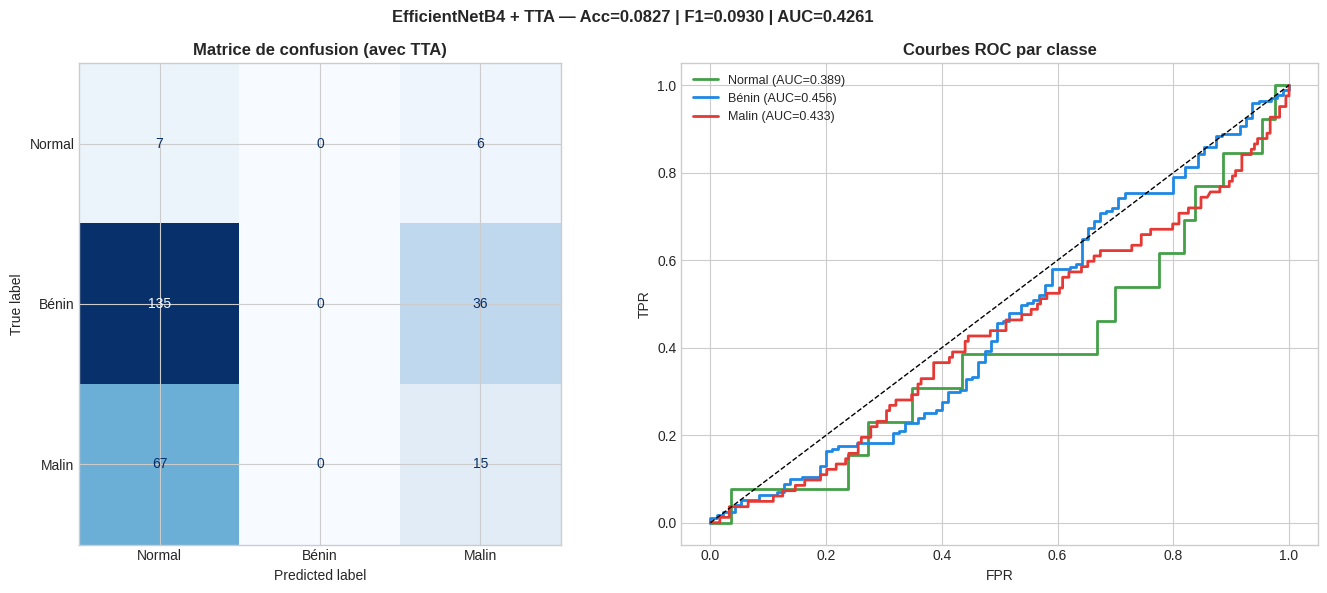

In [17]:
# ─── Évaluation classification avec TTA — Test set ───────────────────────────
clf_model.eval()
all_preds, all_labels, all_probs_list = [], [], []
class_names = ['Normal','Bénin','Malin']

print('🔄 Évaluation avec Test Time Augmentation (TTA x8)...')
for imgs, labels in tqdm(cls_test_loader, desc='TTA Evaluation'):
    imgs = imgs.to(CFG.DEVICE)
    # TTA : moyenne de 8 prédictions augmentées
    probs = predict_tta(clf_model, imgs, n_aug=8).cpu().numpy()
    all_probs_list.extend(probs)
    all_preds.extend(probs.argmax(axis=1))
    all_labels.extend(labels.numpy())

all_probs   = np.array(all_probs_list)
overall_acc = np.mean(np.array(all_preds) == np.array(all_labels))
macro_f1    = f1_score(all_labels, all_preds, average='macro', zero_division=0)

try:
    macro_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
except:
    macro_auc = 0.0

print(f'\n📋 Classification EfficientNetB4 + TTA — Test set :')
print(f'   Accuracy globale : {overall_acc:.4f}')
print(f'   F1-macro         : {macro_f1:.4f}')
print(f'   AUC macro        : {macro_auc:.4f}')
print(f'\n{classification_report(all_labels, all_preds, target_names=class_names)}')

# Matrice de confusion
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'EfficientNetB4 + TTA — Acc={overall_acc:.4f} | F1={macro_f1:.4f} | AUC={macro_auc:.4f}',
             fontsize=12, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds, display_labels=class_names,
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Matrice de confusion (avec TTA)', fontweight='bold')

# Courbes ROC
colors_roc = ['#43A047','#1E88E5','#E53935']
from sklearn.preprocessing import label_binarize
y_bin = label_binarize(all_labels, classes=[0,1,2])
for i, (cls, col) in enumerate(zip(class_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:,i], all_probs[:,i])
    auc_i = roc_auc_score(y_bin[:,i], all_probs[:,i])
    axes[1].plot(fpr, tpr, color=col, lw=2, label=f'{cls} (AUC={auc_i:.3f})')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Courbes ROC par classe', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/clf_evaluation.png', dpi=130, bbox_inches='tight')
plt.show()


In [11]:
# Vérifier l'état du modèle classification
print("=== Diagnostic classification ===")

# 1. Le fichier checkpoint existe ?
CLF_SAVE = os.path.join(PROJECT_DIR, 'EfficientNetB4_clf_best.pth')
print(f"Checkpoint existe : {'✅' if os.path.exists(CLF_SAVE) else '❌ INTROUVABLE'}")

# 2. Tester sur 1 batch sans TTA
clf_model.eval()
imgs, labels = next(iter(cls_test_loader))
with torch.no_grad():
    out   = clf_model(imgs.to(CFG.DEVICE))
    probs = torch.softmax(out, dim=1).cpu()
    preds = probs.argmax(dim=1)

print(f"\nSur 1 batch ({len(labels)} images) :")
print(f"  Labels réels    : {labels.tolist()}")
print(f"  Prédictions     : {preds.tolist()}")
print(f"  Probs moyennes  : Normal={probs[:,0].mean():.3f} | Bénin={probs[:,1].mean():.3f} | Malin={probs[:,2].mean():.3f}")
print(f"\nCFG.LABEL2IDX : {CFG.LABEL2IDX}")

=== Diagnostic classification ===
Checkpoint existe : ❌ INTROUVABLE

Sur 1 batch (16 images) :
  Labels réels    : [1, 1, 1, 0, 1, 1, 2, 2, 1, 1, 1, 1, 2, 2, 2, 1]
  Prédictions     : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Probs moyennes  : Normal=0.328 | Bénin=0.352 | Malin=0.320

CFG.LABEL2IDX : {'normal': 0, 'benign': 1, 'malignant': 2}


In [12]:
# Chercher le checkpoint partout
import glob

print("=== Recherche du checkpoint ===")

# 1. Sur le Drive
for pattern in [
    '/content/drive/MyDrive/**/*.pth',
    '/content/drive/MyDrive/**/*clf*.pth',
    '/content/drive/MyDrive/**/*Efficient*.pth',
]:
    found = glob.glob(pattern, recursive=True)
    if found:
        for f in found:
            print(f'✅ Trouvé : {f}')

# 2. En local (sera perdu à la déco)
for pattern in ['/content/**/*.pth']:
    found = glob.glob(pattern, recursive=True)
    if found:
        for f in found:
            print(f'⚠️  Local seulement (sera perdu) : {f}')

# 3. Vérifier le chemin de sauvegarde dans le code
print(f'\nChemin configuré : {CLF_SAVE}')
print(f'Commence par Drive : {"✅" if CLF_SAVE.startswith("/content/drive") else "❌ NON — sauvegarde locale !"}')

=== Recherche du checkpoint ===
✅ Trouvé : /content/drive/MyDrive/MonProjetCancer/BEST_EfficientNet_UNet.pth
✅ Trouvé : /content/drive/MyDrive/MonProjetCancer/FCN_best.pth
✅ Trouvé : /content/drive/MyDrive/MonProjetCancer/SimpleUNet_best.pth
✅ Trouvé : /content/drive/MyDrive/MonProjetCancer/SegNet_best.pth
✅ Trouvé : /content/drive/MyDrive/MonProjetCancer/Attention_UNet_best.pth
✅ Trouvé : /content/drive/MyDrive/MonProjetCancer/TransUNet_best.pth
✅ Trouvé : /content/drive/MyDrive/MonProjetCancer/ResNet34_UNet_best.pth
✅ Trouvé : /content/drive/MyDrive/MonProjetCancer/EfficientNet_UNet_best.pth
✅ Trouvé : /content/drive/MyDrive/MonProjetCancer/DeepLabV3Plus_best.pth
✅ Trouvé : /content/drive/MyDrive/MonProjetcancer/EfficientNetB0_clf_best.pth
✅ Trouvé : /content/drive/MyDrive/MonProjetcancer/BEST_ResNet34_UNet.pth
✅ Trouvé : /content/drive/MyDrive/MonProjetcancer/BEST_ResNet34_UNet_BUSI_BUSBRA.pth
✅ Trouvé : /content/drive/MyDrive/MonProjetcancer/BEST_ResNet50_UNet_SCSE.pth
✅ Trouvé : /

In [13]:
import torchvision.models as tv

# ─── Charger EfficientNetB0 déjà entraîné ────────────────────────────────────
CLF_B0_SAVE = '/content/drive/MyDrive/MonProjetcancer/EfficientNetB0_clf_best.pth'

clf_model = tv.efficientnet_b0(weights=None)
in_features = clf_model.classifier[1].in_features
clf_model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.2),
    nn.Linear(256, 3)
)
clf_model.load_state_dict(torch.load(CLF_B0_SAVE, map_location=CFG.DEVICE))
clf_model = clf_model.to(CFG.DEVICE)
clf_model.eval()
print(f'✅ EfficientNetB0 chargé depuis : {CLF_B0_SAVE}')

# ─── Évaluation rapide SANS TTA ───────────────────────────────────────────────
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in cls_test_loader:
        out   = clf_model(imgs.to(CFG.DEVICE))
        probs = torch.softmax(out, dim=1).cpu()
        all_probs.append(probs)
        all_preds.extend(probs.argmax(dim=1).tolist())
        all_labels.extend(labels.tolist())

all_probs  = torch.cat(all_probs).numpy()
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

from sklearn.metrics import classification_report, accuracy_score
acc = accuracy_score(all_labels, all_preds)
print(f'\n📋 EfficientNetB0 — Test set :')
print(f'   Accuracy : {acc:.4f}')
print(classification_report(all_labels, all_preds,
      target_names=[CFG.IDX2LABEL[i] for i in range(3)]))

✅ EfficientNetB0 chargé depuis : /content/drive/MyDrive/MonProjetcancer/EfficientNetB0_clf_best.pth

📋 EfficientNetB0 — Test set :
   Accuracy : 0.6278
              precision    recall  f1-score   support

      Normal       0.30      1.00      0.46        13
       Bénin       0.81      0.62      0.70       171
       Malin       0.53      0.59      0.55        82

    accuracy                           0.63       266
   macro avg       0.54      0.74      0.57       266
weighted avg       0.70      0.63      0.64       266



In [14]:
# ─── Fine-tuning EfficientNetB0 avec class weights ───────────────────────────
from sklearn.utils.class_weight import compute_class_weight

# Calculer les poids de classe pour compenser le déséquilibre
class_weights = compute_class_weight('balanced',
                                     classes=np.array([0, 1, 2]),
                                     y=train_df['label_idx'].values)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(CFG.DEVICE)
print(f'Class weights : Normal={class_weights[0]:.2f} | Bénin={class_weights[1]:.2f} | Malin={class_weights[2]:.2f}')

# Loss pondérée
criterion_clf = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# Dégeler toutes les couches pour fine-tuning
for p in clf_model.parameters():
    p.requires_grad = True

optimizer_clf = torch.optim.AdamW(clf_model.parameters(), lr=2e-5, weight_decay=1e-4)
scheduler_clf = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_clf, T_max=20, eta_min=1e-7)

CLF_SAVE_V2   = '/content/drive/MyDrive/MonProjetcancer/EfficientNetB0_clf_v2.pth'
best_clf_acc  = 0.63
patience, patience_ctr = 8, 0

print(f'🚀 Fine-tuning EfficientNetB0 — 20 epochs | LR=2e-5')
print('-' * 55)

for epoch in range(1, 21):
    clf_model.train(); tr_loss = 0; tr_correct = 0; tr_total = 0
    for imgs, labels in tqdm(cls_train_loader, desc=f'Epoch {epoch:02d}/20', leave=False):
        imgs, labels = imgs.to(CFG.DEVICE), labels.to(CFG.DEVICE)
        optimizer_clf.zero_grad()
        out  = clf_model(imgs)
        loss = criterion_clf(out, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(clf_model.parameters(), 1.0)
        optimizer_clf.step()
        tr_loss    += loss.item()
        tr_correct += (out.argmax(1) == labels).sum().item()
        tr_total   += len(labels)
    scheduler_clf.step()

    clf_model.eval(); val_correct = 0; val_total = 0
    all_vp, all_vl = [], []
    with torch.no_grad():
        for imgs, labels in cls_val_loader:
            out = clf_model(imgs.to(CFG.DEVICE))
            val_correct += (out.argmax(1) == labels.to(CFG.DEVICE)).sum().item()
            val_total   += len(labels)
            all_vp.extend(out.argmax(1).cpu().tolist())
            all_vl.extend(labels.tolist())

    tr_acc  = tr_correct / tr_total
    val_acc = val_correct / val_total
    print(f'Epoch {epoch:02d} | Loss={tr_loss/len(cls_train_loader):.4f} | TrainAcc={tr_acc:.4f} | ValAcc={val_acc:.4f}')

    if val_acc > best_clf_acc:
        best_clf_acc = val_acc
        torch.save(clf_model.state_dict(), CLF_SAVE_V2)
        print(f'   ✅ Meilleure accuracy : {best_clf_acc:.4f} — sauvegardé !')
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f'   ⏹ Early stopping epoch {epoch}')
            break

print(f'\n✅ Meilleure accuracy finale : {best_clf_acc:.4f}')

Class weights : Normal=6.64 | Bénin=0.52 | Malin=1.08
🚀 Fine-tuning EfficientNetB0 — 20 epochs | LR=2e-5
-------------------------------------------------------


Epoch 01 | Loss=1.3032 | TrainAcc=0.5660 | ValAcc=0.6131


Epoch 02 | Loss=1.1542 | TrainAcc=0.5379 | ValAcc=0.6307
   ✅ Meilleure accuracy : 0.6307 — sauvegardé !


Epoch 03 | Loss=1.1355 | TrainAcc=0.5671 | ValAcc=0.6583
   ✅ Meilleure accuracy : 0.6583 — sauvegardé !


Epoch 04 | Loss=1.1058 | TrainAcc=0.5731 | ValAcc=0.7060
   ✅ Meilleure accuracy : 0.7060 — sauvegardé !


...

Epoch 16 | Loss=1.0015 | TrainAcc=0.6906 | ValAcc=0.7588


Epoch 17 | Loss=0.9899 | TrainAcc=0.6941 | ValAcc=0.7663


Epoch 18 | Loss=1.0102 | TrainAcc=0.6866 | ValAcc=0.7714


Epoch 19 | Loss=1.0014 | TrainAcc=0.6901 | ValAcc=0.7764


Epoch 20 | Loss=1.0231 | TrainAcc=0.6816 | ValAcc=0.7688
   ⏹ Early stopping epoch 20

✅ Meilleure accuracy finale : 0.7789


In [15]:
# ─── Continuer le fine-tuning depuis le meilleur checkpoint ──────────────────
clf_model.load_state_dict(torch.load(CLF_SAVE_V2, map_location=CFG.DEVICE))

optimizer_clf = torch.optim.AdamW(clf_model.parameters(), lr=5e-6, weight_decay=1e-4)
scheduler_clf = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_clf, T_max=20, eta_min=1e-8)

best_clf_acc   = 0.7789
patience, patience_ctr = 10, 0

print(f'🚀 Fine-tuning phase 2 — 20 epochs | LR=5e-6')
print('-' * 55)

for epoch in range(1, 21):
    clf_model.train(); tr_loss = 0; tr_correct = 0; tr_total = 0
    for imgs, labels in tqdm(cls_train_loader, desc=f'Epoch {epoch:02d}/20', leave=False):
        imgs, labels = imgs.to(CFG.DEVICE), labels.to(CFG.DEVICE)
        optimizer_clf.zero_grad()
        loss = criterion_clf(out := clf_model(imgs), labels)
        loss.backward()
        nn.utils.clip_grad_norm_(clf_model.parameters(), 1.0)
        optimizer_clf.step()
        tr_loss    += loss.item()
        tr_correct += (out.argmax(1) == labels).sum().item()
        tr_total   += len(labels)
    scheduler_clf.step()

    clf_model.eval(); val_correct = 0; val_total = 0
    with torch.no_grad():
        for imgs, labels in cls_val_loader:
            out = clf_model(imgs.to(CFG.DEVICE))
            val_correct += (out.argmax(1) == labels.to(CFG.DEVICE)).sum().item()
            val_total   += len(labels)

    tr_acc  = tr_correct / tr_total
    val_acc = val_correct / val_total
    print(f'Epoch {epoch:02d} | Loss={tr_loss/len(cls_train_loader):.4f} | TrainAcc={tr_acc:.4f} | ValAcc={val_acc:.4f}')

    if val_acc > best_clf_acc:
        best_clf_acc = val_acc
        torch.save(clf_model.state_dict(), CLF_SAVE_V2)
        print(f'   ✅ Meilleure accuracy : {best_clf_acc:.4f} — sauvegardé !')
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f'   ⏹ Early stopping epoch {epoch}')
            break

clf_model.load_state_dict(torch.load(CLF_SAVE_V2, map_location=CFG.DEVICE))
print(f'\n✅ Meilleure accuracy finale : {best_clf_acc:.4f}')

# ─── Évaluation finale sur test set ──────────────────────────────────────────
from sklearn.metrics import classification_report, accuracy_score

clf_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in cls_test_loader:
        out = clf_model(imgs.to(CFG.DEVICE))
        all_preds.extend(out.argmax(1).cpu().tolist())
        all_labels.extend(labels.tolist())

acc = accuracy_score(all_labels, all_preds)
print(f'\n📋 Résultats finaux — Test set :')
print(f'   Accuracy : {acc:.4f}')
print(classification_report(all_labels, all_preds,
      target_names=[CFG.IDX2LABEL[i] for i in range(3)]))

🚀 Fine-tuning phase 2 — 20 epochs | LR=5e-6
-------------------------------------------------------


Epoch 01 | Loss=1.0037 | TrainAcc=0.6851 | ValAcc=0.7789


Epoch 02 | Loss=1.0102 | TrainAcc=0.6846 | ValAcc=0.7789


Epoch 03 | Loss=1.0262 | TrainAcc=0.6806 | ValAcc=0.7789


Epoch 04 | Loss=1.0081 | TrainAcc=0.6896 | ValAcc=0.7663


...

Epoch 16 | Loss=0.9939 | TrainAcc=0.6931 | ValAcc=0.7739


Epoch 17 | Loss=0.9891 | TrainAcc=0.7137 | ValAcc=0.7965
   ✅ Meilleure accuracy : 0.7965 — sauvegardé !


Epoch 18 | Loss=1.0019 | TrainAcc=0.7002 | ValAcc=0.7990
   ✅ Meilleure accuracy : 0.7990 — sauvegardé !


Epoch 19 | Loss=0.9892 | TrainAcc=0.7072 | ValAcc=0.7739


Epoch 20 | Loss=0.9716 | TrainAcc=0.7142 | ValAcc=0.7764

✅ Meilleure accuracy finale : 0.7990

📋 Résultats finaux — Test set :
   Accuracy : 0.8008
              precision    recall  f1-score   support

      Normal       0.48      1.00      0.65        13
       Bénin       0.91      0.81      0.85       171
       Malin       0.71      0.76      0.73        82

    accuracy                           0.80       266
   macro avg       0.70      0.85      0.75       266
weighted avg       0.83      0.80      0.81       266



In [16]:
# ─── Phase 3 — LR encore plus bas ────────────────────────────────────────────
clf_model.load_state_dict(torch.load(CLF_SAVE_V2, map_location=CFG.DEVICE))

optimizer_clf = torch.optim.AdamW(clf_model.parameters(), lr=1e-6, weight_decay=1e-4)
scheduler_clf = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_clf, T_max=20, eta_min=1e-9)

best_clf_acc   = 0.7990
patience, patience_ctr = 10, 0

print(f'🚀 Fine-tuning phase 3 — 20 epochs | LR=1e-6')
print('-' * 55)

for epoch in range(1, 21):
    clf_model.train(); tr_loss = 0; tr_correct = 0; tr_total = 0
    for imgs, labels in tqdm(cls_train_loader, desc=f'Epoch {epoch:02d}/20', leave=False):
        imgs, labels = imgs.to(CFG.DEVICE), labels.to(CFG.DEVICE)
        optimizer_clf.zero_grad()
        loss = criterion_clf(out := clf_model(imgs), labels)
        loss.backward()
        nn.utils.clip_grad_norm_(clf_model.parameters(), 1.0)
        optimizer_clf.step()
        tr_loss    += loss.item()
        tr_correct += (out.argmax(1) == labels).sum().item()
        tr_total   += len(labels)
    scheduler_clf.step()

    clf_model.eval(); val_correct = 0; val_total = 0
    with torch.no_grad():
        for imgs, labels in cls_val_loader:
            out = clf_model(imgs.to(CFG.DEVICE))
            val_correct += (out.argmax(1) == labels.to(CFG.DEVICE)).sum().item()
            val_total   += len(labels)

    tr_acc  = tr_correct / tr_total
    val_acc = val_correct / val_total
    print(f'Epoch {epoch:02d} | Loss={tr_loss/len(cls_train_loader):.4f} | TrainAcc={tr_acc:.4f} | ValAcc={val_acc:.4f}')

    if val_acc > best_clf_acc:
        best_clf_acc = val_acc
        torch.save(clf_model.state_dict(), CLF_SAVE_V2)
        print(f'   ✅ Meilleure accuracy : {best_clf_acc:.4f} — sauvegardé !')
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f'   ⏹ Early stopping epoch {epoch}')
            break

clf_model.load_state_dict(torch.load(CLF_SAVE_V2, map_location=CFG.DEVICE))
print(f'\n✅ Meilleure accuracy finale : {best_clf_acc:.4f}')

clf_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in cls_test_loader:
        out = clf_model(imgs.to(CFG.DEVICE))
        all_preds.extend(out.argmax(1).cpu().tolist())
        all_labels.extend(labels.tolist())

acc = accuracy_score(all_labels, all_preds)
print(f'\n📋 Résultats test set phase 3 :')
print(f'   Accuracy : {acc:.4f}')
print(classification_report(all_labels, all_preds,
      target_names=[CFG.IDX2LABEL[i] for i in range(3)]))

🚀 Fine-tuning phase 3 — 20 epochs | LR=1e-6
-------------------------------------------------------


Epoch 01 | Loss=0.9754 | TrainAcc=0.7212 | ValAcc=0.7814


Epoch 02 | Loss=0.9833 | TrainAcc=0.6971 | ValAcc=0.7839


Epoch 03 | Loss=0.9758 | TrainAcc=0.7077 | ValAcc=0.7688


Epoch 04 | Loss=0.9764 | TrainAcc=0.7122 | ValAcc=0.7538


...

Epoch 06 | Loss=0.9926 | TrainAcc=0.7067 | ValAcc=0.7663


Epoch 07 | Loss=0.9833 | TrainAcc=0.7152 | ValAcc=0.7864


Epoch 08 | Loss=0.9856 | TrainAcc=0.7137 | ValAcc=0.7764


Epoch 09 | Loss=0.9980 | TrainAcc=0.7157 | ValAcc=0.7864


Epoch 10 | Loss=1.0080 | TrainAcc=0.6966 | ValAcc=0.7864
   ⏹ Early stopping epoch 10

✅ Meilleure accuracy finale : 0.7990

📋 Résultats test set phase 3 :
   Accuracy : 0.8008
              precision    recall  f1-score   support

      Normal       0.48      1.00      0.65        13
       Bénin       0.91      0.81      0.85       171
       Malin       0.71      0.76      0.73        82

    accuracy                           0.80       266
   macro avg       0.70      0.85      0.75       266
weighted avg       0.83      0.80      0.81       266



## 🎯 7. Grad-CAM (identique à avant)

In [17]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients, self.activations = None, None
        target_layer.register_forward_hook(lambda m,i,o: setattr(self,'activations',o))
        target_layer.register_backward_hook(lambda m,gi,go: setattr(self,'gradients',go[0]))

    def __call__(self, x, class_idx=None):
        self.model.eval()
        out = self.model(x)
        self.model.zero_grad()
        if class_idx is None:
            class_idx = out.argmax(dim=1).item()
        out[0, class_idx].backward()
        if self.gradients is not None and self.activations is not None:
            weights = self.gradients.mean(dim=(2,3), keepdim=True)
            cam = (weights * self.activations).sum(dim=1).squeeze().cpu().detach().numpy()
            cam = np.maximum(cam, 0)
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        else:
            cam = np.zeros_like(x[0,0].cpu().numpy())
        return cam, class_idx

# EfficientNetB4 : le dernier bloc features est l'index 8 (MBConv block)
# Vérification dynamique pour éviter les IndexError
target_layer = clf_model.features[-1]  # dernier bloc de features B4
gradcam = GradCAM(clf_model, target_layer)

def apply_gradcam_overlay(img_np, cam, alpha=0.45):
    cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
    heatmap = cv2.applyColorMap((cam_resized*255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    overlay = (1-alpha) * img_np + alpha * heatmap
    return np.clip(overlay, 0, 1), cam_resized

print('✅ GradCAM prêt')

✅ GradCAM prêt


## 📊 8. Tableau récapitulatif des métriques

NameError: name 'class_names' is not defined

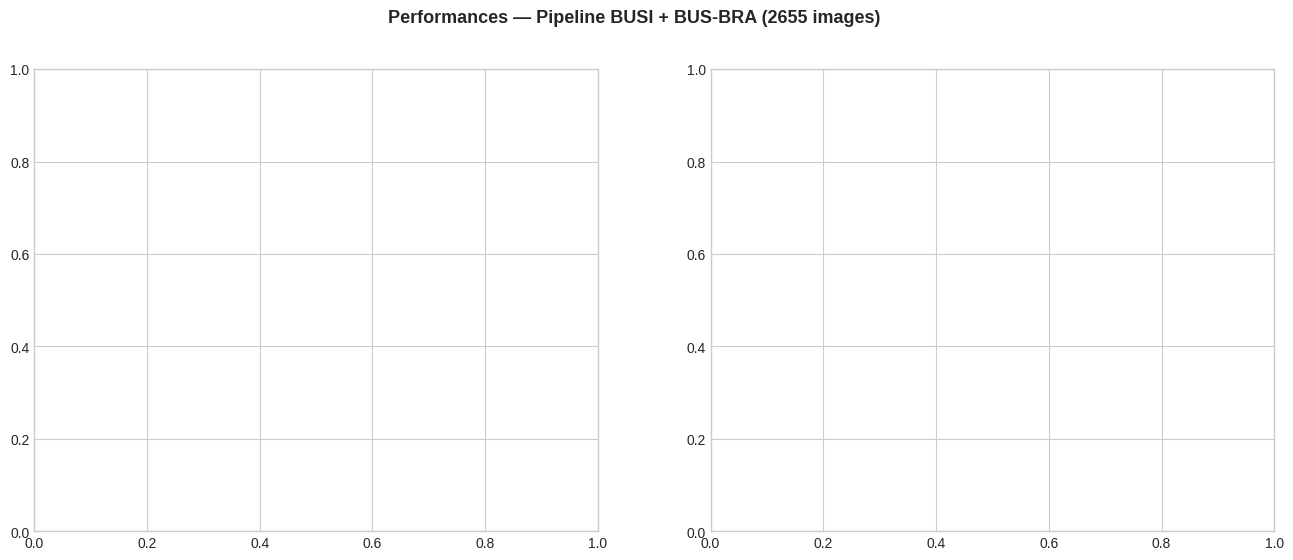

In [18]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Performances — Pipeline BUSI + BUS-BRA ({len(df)} images)', fontsize=13, fontweight='bold')

prec, rec, f1, sup = precision_recall_fscore_support(all_labels, all_preds, average=None)
clf_metrics_df = pd.DataFrame({
    'Classe'    : class_names,
    'Précision' : prec.round(3),
    'Rappel'    : rec.round(3),
    'F1-Score'  : f1.round(3),
    'Support'   : sup.astype(int)
})

x = np.arange(len(class_names)); w = 0.25
axes[0].bar(x-w, prec, w, label='Précision', color='#2196F3', alpha=0.85)
axes[0].bar(x,   rec,  w, label='Rappel',    color='#4CAF50', alpha=0.85)
axes[0].bar(x+w, f1,   w, label='F1-Score',  color='#FF9800', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(class_names)
axes[0].set_ylim(0, 1.1); axes[0].set_title('Métriques par classe (Classification)', fontsize=11)
axes[0].legend(fontsize=9)
for xi,p,r,f in zip(x,prec,rec,f1):
    for val,off in [(p,-w),(r,0),(f,w)]:
        axes[0].text(xi+off, val+0.02, f'{val:.2f}', ha='center', fontsize=8)

seg_names  = ['Dice','IoU','Précision','Rappel']
seg_vals   = [seg_metrics_final[k] for k in ['dice','iou','precision','recall']]
seg_colors = ['#9C27B0','#00BCD4','#2196F3','#4CAF50']
bars = axes[1].barh(seg_names, seg_vals, color=seg_colors, alpha=0.85, edgecolor='white')
axes[1].set_xlim(0, 1.1)
axes[1].set_title('Métriques segmentation ResNet34-UNet (test set)', fontsize=11)
for bar, val in zip(bars, seg_vals):
    axes[1].text(val+0.02, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/metrics_summary.png', dpi=130, bbox_inches='tight')
plt.show()

print('📋 Métriques Classification :')
print(clf_metrics_df.to_string(index=False))
print(f'\n   Accuracy globale : {overall_acc:.4f}')
print(f'   AUC macro        : {macro_auc:.4f}')
print('\n📋 Métriques Segmentation :')
for k,v in seg_metrics_final.items():
    print(f'   {k:12s}: {v:.4f}')

## 🩺 9. Rapport IA Médical — Dashboard Final

In [19]:
def compute_ai_risk_score(probs, seg_coverage, gradcam_intensity):
    p_malin   = float(probs[2])
    seg_score = min(seg_coverage / 30.0, 1.0)
    cam_score = float(np.mean(gradcam_intensity > 0.5))
    composite = 0.60 * p_malin + 0.25 * seg_score + 0.15 * cam_score
    return round(composite * 100, 1)

def risk_level(score):
    if score < 25: return '🟢 Faible',   '#27ae60'
    if score < 55: return '🟡 Modéré',   '#f39c12'
    if score < 75: return '🟠 Élevé',    '#e67e22'
    return              '🔴 Très élevé','#c0392b'

def generate_report(image_path_or_array, true_label=None):
    if isinstance(image_path_or_array, str):
        raw = cv2.imread(image_path_or_array)
        img_orig = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
    else:
        img_orig = np.array(image_path_or_array)
        if img_orig.dtype != np.uint8:
            img_orig = (np.clip(img_orig,0,1)*255).astype(np.uint8)

    tf_val = get_transforms('val')
    tensor = tf_val(image=img_orig)['image'].unsqueeze(0).to(CFG.DEVICE)
    img_display = cv2.resize(img_orig,(CFG.IMG_SIZE,CFG.IMG_SIZE)).astype(np.float32)/255.0

    seg_model.eval()
    with torch.no_grad():
        pred_raw = torch.sigmoid(seg_model(tensor))[0,0].cpu().numpy()
    seg_clean    = postprocess_mask(pred_raw)
    seg_coverage = seg_clean.mean() * 100

    clf_model.eval()
    with torch.no_grad():
        logits = clf_model(tensor)
        probs  = F.softmax(logits, dim=1)[0].cpu().numpy()
    pred_class = int(probs.argmax())
    pred_label = CFG.IDX2LABEL[pred_class]

    cam_map, _ = gradcam(tensor, class_idx=pred_class)
    overlay_gradcam, cam_resized = apply_gradcam_overlay(img_display, cam_map)

    ai_score = compute_ai_risk_score(probs, seg_coverage, cam_resized)
    risk_lbl, risk_color = risk_level(ai_score)

    fig = plt.figure(figsize=(22, 12), facecolor='#f8f9fa')
    gs  = fig.add_gridspec(3, 5, hspace=0.35, wspace=0.35,
                           left=0.04, right=0.96, top=0.88, bottom=0.05)

    diag_color = {'Normal':'#27ae60','Bénin':'#2980b9','Malin':'#c0392b'}[pred_label]
    true_str   = f' | GT : {true_label.capitalize()}' if true_label else ''
    n_total    = len(df_busi) + len(df_busbra)
    fig.suptitle(
        f'🩺 RAPPORT IA — Analyse Échographie Mammaire\n'
        f'Prédiction : {pred_label.upper()}{true_str}  |  '
        f'Indice de suspicion : {ai_score}/100 {risk_lbl}  |  '
        f'Entraîné sur {n_total} images (BUSI + BUS-BRA)',
        fontsize=12, fontweight='bold', color=diag_color, y=0.97
    )

    ax1 = fig.add_subplot(gs[0,0])
    ax1.imshow(img_display); ax1.set_title('Image ultrason\noriginale', fontsize=9, fontweight='bold'); ax1.axis('off')

    ax2 = fig.add_subplot(gs[0,1])
    im2 = ax2.imshow(pred_raw, cmap='hot', vmin=0, vmax=1)
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    ax2.set_title('Heatmap segmentation\nResNet34-UNet', fontsize=9, fontweight='bold'); ax2.axis('off')

    ax3 = fig.add_subplot(gs[0,2])
    ax3.imshow(img_display)
    if seg_clean.sum() > 0:
        rgba = np.zeros((*seg_clean.shape,4), dtype=np.float32)
        rgba[seg_clean>0] = [0.9,0.1,0.1,0.55]
        ax3.imshow(rgba)
    ax3.set_title(f'Région tumorale\n({seg_coverage:.1f}% surface)', fontsize=9, fontweight='bold'); ax3.axis('off')

    ax4 = fig.add_subplot(gs[0,3])
    ax4.imshow(cam_resized, cmap='jet', vmin=0, vmax=1)
    ax4.set_title('Grad-CAM\nZones attention', fontsize=9, fontweight='bold'); ax4.axis('off')

    ax5 = fig.add_subplot(gs[0,4])
    ax5.imshow(overlay_gradcam)
    ax5.set_title('Grad-CAM overlay', fontsize=9, fontweight='bold'); ax5.axis('off')

    ax6 = fig.add_subplot(gs[1,:2])
    bar_colors = ['#27ae60','#2980b9','#c0392b']
    bars_prob = ax6.bar(class_names, probs*100, color=bar_colors, alpha=0.85, edgecolor='white', linewidth=1.5)
    ax6.set_ylim(0,115); ax6.set_ylabel('Probabilité (%)')
    ax6.set_title('Distribution probabilités — Classifier IA', fontsize=10, fontweight='bold')
    for bar,val in zip(bars_prob, probs*100):
        ax6.text(bar.get_x()+bar.get_width()/2, val+2, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
    bars_prob[pred_class].set_edgecolor('black'); bars_prob[pred_class].set_linewidth(3)

    ax7 = fig.add_subplot(gs[1,2]); ax7.axis('off')
    ax7.set_xlim(-1.3,1.3); ax7.set_ylim(-1.3,1.3)
    ax7.add_patch(plt.Circle((0,0),1.1,color='#ecf0f1',zorder=0))
    arc_theta = np.linspace(-np.pi/2, -np.pi/2+2*np.pi*(ai_score/100), 100)
    ax7.plot(np.cos(arc_theta)*1.0, np.sin(arc_theta)*1.0, linewidth=12, color=risk_color, solid_capstyle='round')
    ax7.text(0, 0.1, f'{ai_score}', ha='center', va='center', fontsize=28, fontweight='bold', color=risk_color)
    ax7.text(0,-0.35,'/100', ha='center', fontsize=11, color='gray')
    ax7.text(0,-0.65, risk_lbl, ha='center', fontsize=10, fontweight='bold', color=risk_color)
    ax7.set_title('Indice de\nsuspicion IA', fontsize=10, fontweight='bold')

    ax8 = fig.add_subplot(gs[1,3:]); ax8.axis('off')
    tdata = [
        ['Dataset', f'BUSI ({len(df_busi)}) + BUS-BRA ({len(df_busbra)})'],
        ['Modèle segmentation', 'ResNet34-UNet (SMP)'],
        ['Loss segmentation',   f'BCE+Dice ({CFG.BCE_WEIGHT}/{CFG.DICE_WEIGHT})'],
        ['Dice (test set)',      f'{seg_metrics_final["dice"]:.4f}'],
        ['IoU (test set)',       f'{seg_metrics_final["iou"]:.4f}'],
        ['Modèle classification','EfficientNetB4'],
        ['Accuracy globale',    f'{overall_acc:.4f}'],
        ['AUC macro (ROC)',      f'{macro_auc:.4f}'],
        ['Surface lésion',       f'{seg_coverage:.1f}%'],
        ['Confiance modèle',     f'{float(probs.max())*100:.1f}%'],
    ]
    tbl = ax8.table(cellText=tdata, colLabels=['Indicateur','Valeur'],
                    cellLoc='center', loc='center', colWidths=[0.55,0.35])
    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.2, 1.6)
    for (r,c),cell in tbl.get_celld().items():
        if r==0: cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white',fontweight='bold')
        elif r%2==0: cell.set_facecolor('#f2f3f4')
    ax8.set_title('Résumé des performances modèles', fontsize=10, fontweight='bold')

    ax9 = fig.add_subplot(gs[2,:]); ax9.axis('off')
    disclaimer = (
        '⚠️  AVERTISSEMENT MÉDICAL : Ce rapport est généré par un système d\'Intelligence Artificielle '
        'à des fins académiques uniquement.\n'
        'L\'indice de suspicion IA est un score composite expérimental et NE constitue PAS un diagnostic médical.\n'
        'Toute décision clinique doit être prise par un médecin radiologue qualifié sur la base d\'un examen complet.'
    )
    ax9.text(0.5, 0.5, disclaimer, transform=ax9.transAxes,
             fontsize=8, ha='center', va='center', style='italic',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffeeba', alpha=0.8, edgecolor='#f39c12'))

    plt.savefig(f'{OUTPUT_DIR}/rapport_medical_ia.png', dpi=150, bbox_inches='tight', facecolor='#f8f9fa')
    plt.show()

    return {
        'prediction'      : pred_label,
        'probabilities'   : {CFG.IDX2LABEL[i]:round(float(probs[i]),4) for i in range(3)},
        'seg_coverage_pct': round(seg_coverage,2),
        'ai_risk_score'   : ai_score,
        'risk_level'      : risk_lbl,
        'seg_dice'        : seg_metrics_final['dice'],
        'clf_accuracy'    : round(overall_acc,4),
    }

print('✅ generate_report() défini.')

✅ generate_report() défini.


In [20]:
# ─── Rapport sur les 3 classes ────────────────────────────────────────────────
for cls in ['normal','benign','malignant']:
    subset = test_df[test_df['label']==cls]
    if len(subset)==0: subset = df[df['label']==cls]
    row = subset.sample(1, random_state=7).iloc[0]
    print(f'\n--- {cls.upper()} ---')
    generate_report(row['image'], true_label=row['label'])


--- NORMAL ---


NameError: name 'seg_model' is not defined

## 💾 10. Sauvegarde Drive

In [ ]:
import shutil

torch.save(seg_model.state_dict(), os.path.join(PROJECT_DIR,'BEST_ResNet34_UNet_BUSI_BUSBRA.pth'))
torch.save(clf_model.state_dict(), os.path.join(PROJECT_DIR,'EfficientNetB4_clf_BUSI_BUSBRA.pth'))

figures_dir = os.path.join(PROJECT_DIR,'figures')
os.makedirs(figures_dir, exist_ok=True)
for f in os.listdir(OUTPUT_DIR):
    if f.endswith('.png'):
        shutil.copy(os.path.join(OUTPUT_DIR,f), os.path.join(figures_dir,f))

print('✅ Modèles et figures sauvegardés sur Drive.')
print(f'   Dossier : {PROJECT_DIR}')
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f'   📄 {f}')

## 📚 Références

| Composant | Référence |
|---|---|
| Dataset BUSI | Al-Dhabyani et al., *Data in Brief*, 2020 |
| Dataset BUS-BRA | Gómez-Flores W. et al., *Medical Physics*, vol. 51, pp. 3110–3123, 2024. DOI: 10.1002/mp.16812 |
| ResNet34-UNet | Ronneberger et al., *MICCAI*, 2015 + He et al., *CVPR*, 2016 |
| BCE+Dice Loss | Sudre et al., *DLMIA Workshop*, 2017 |
| EfficientNet | Tan & Le, *ICML*, 2019 |
| Grad-CAM | Selvaraju et al., *ICCV*, 2017 |
| SMP Library | Iakubovskii, 2019 |
| Albumentations | Buslaev et al., *Information*, 2020 |

> **Améliorations v2 (BUSI + BUS-BRA) :**
> - Dataset x3.4 plus grand (780 → ~2655 images, 4 scanners différents)
> - Loss combinée BCE+Dice pour meilleure gestion des petites lésions
> - Augmentations renforcées (GaussNoise + RandomGamma) pour robustesse multi-scanner
> - Scheduler CosineAnnealingWarmRestarts pour une meilleure convergence